In [1]:
# BRAIN TUMOR MRI CLASSIFICATION
# A Comparative Study: VGG16 vs ResNet50 vs EfficientNetB0
# Author: Amrit Rajkumar | DC2024BTE0184
# Assam Don Bosco University | B.Tech AIML | Batch 2024-2028
# Supervisor: Dr. Nilakshi Devi

# ── PART 1: SETUP, IMPORTS & DATASET PREPARATION ──────────────────────────
# Step 1 — Install extra libraries not pre-installed on Kaggle
# tf-keras-vis is needed later for GradCAM visualization
!pip install -q tf-keras-vis

# Step 2 — All imports
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')
print("All libraries imported successfully.")


# Step 3 — Project folder structure on Kaggle
# On Kaggle:
#   /kaggle/input/  → read-only dataset (added via "+ Add Data" button)
#   /kaggle/working/ → writable output folder (models, plots saved here)
#
# IMPORTANT: Before running this notebook, add the dataset via:
#   "+ Add Data" → search "Brain Tumor MRI Dataset" by Masoud Nickparvar
#   (dataset slug: masoudnickparvar/brain-tumor-mri-dataset)

DATASET_DIR = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset'
MODELS_DIR  = '/kaggle/working/models'
OUTPUT_DIR  = '/kaggle/working/outputs'

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Project folder structure:")
print(f"  Dataset  → {DATASET_DIR}")
print(f"  Models   → {MODELS_DIR}")
print(f"  Outputs  → {OUTPUT_DIR}")


# Step 4 — Dataset paths
# Kaggle extracts the dataset directly into /kaggle/input/<dataset-slug>/
# No download or extraction needed — it's already there.

TRAIN_DIR = os.path.join(DATASET_DIR, 'Training')
TEST_DIR  = os.path.join(DATASET_DIR, 'Testing')

print(f"\n  Train dir : {TRAIN_DIR}")
print(f"  Test  dir : {TEST_DIR}")


# Step 5 — Global configuration
# All important settings in one place — change here, applies everywhere

IMG_SIZE    = 224       # input size required by VGG16, ResNet50, EfficientNetB0
BATCH_SIZE  = 64
NUM_CLASSES = 4
SEED        = 42
EPOCHS_P1   = 20        # phase 1: train with frozen base
EPOCHS_P2   = 30        # phase 2: fine-tune upper layers
LR_P1       = 1e-3      # learning rate for phase 1
LR_P2       = 1e-5      # much lower LR for fine-tuning
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']


# Step 6 — Set random seeds for reproducibility
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"Random seed set to {SEED}.")


# Step 7 — Check GPU
# On Kaggle: Settings (right panel) → Accelerator → GPU T4 x2 or P100
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPUs available: {len(gpus)}")
else:
    print("WARNING: No GPU detected. Go to Settings → Accelerator → GPU.")

# Enable mixed precision for faster GPU training
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
print("Mixed precision enabled.")


# Step 8 — Verify dataset counts
print("\nDataset verification:")
for split, path in [('Training', TRAIN_DIR), ('Testing', TEST_DIR)]:
    total = 0
    for cls in CLASS_NAMES:
        count = len(os.listdir(os.path.join(path, cls)))
        total += count
        print(f"  [{split}] {cls}: {count} images")
    print(f"  [{split}] TOTAL: {total}\n")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 650.3 kB/s eta 0:00:000:00:01


2026-05-19 04:31:52.651797: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779165112.816187      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779165112.865090      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779165113.254903      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779165113.254951      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779165113.254954      57 computation_placer.cc:177] computation placer alr

All libraries imported successfully.
Project folder structure:
  Dataset  → /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset
  Models   → /kaggle/working/models
  Outputs  → /kaggle/working/outputs

  Train dir : /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training
  Test  dir : /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing
Random seed set to 42.
GPUs available: 2
Mixed precision enabled.

Dataset verification:
  [Training] glioma: 1400 images
  [Training] meningioma: 1400 images
  [Training] notumor: 1400 images
  [Training] pituitary: 1400 images
  [Training] TOTAL: 5600

  [Testing] glioma: 400 images
  [Testing] meningioma: 400 images
  [Testing] notumor: 400 images
  [Testing] pituitary: 400 images
  [Testing] TOTAL: 1600



### Part 2 — Data Loading & Preprocessing

Here we load the MRI images from the dataset folders and prepare them for training.

Since the models expect images of a fixed size with pixel values between **0 and 1**, we need to resize and normalize every image before it enters the model.

We also apply **data augmentation** on the training images — this means randomly flipping, rotating, and slightly zooming images to create variety. This helps the model generalize better and not just memorize the training data.

The dataset has no separate validation folder, so we take **20% of the training data as validation** automatically. This gives us three splits — **train, validation, and test**.

The test generator gets **no augmentation — only normalization**. We never modify test images because the test set must represent real unseen data exactly as it is.

Finally, we print a summary and plot sample images from each class to visually confirm everything loaded correctly.

In [2]:
# ── PART 2: DATA LOADING & PREPROCESSING ──────────────────────────────────

# NO rescale here — preprocessing is handled inside each model via Lambda layer
train_datagen = ImageDataGenerator(
    horizontal_flip    = True,
    rotation_range     = 20,
    zoom_range         = 0.15,
    width_shift_range  = 0.1,
    height_shift_range = 0.1,
    validation_split   = 0.2
)

test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size  = (IMG_SIZE, IMG_SIZE),
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    subset       = 'training',
    shuffle      = True,
    seed         = SEED,
    classes      = CLASS_NAMES
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size  = (IMG_SIZE, IMG_SIZE),
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    subset       = 'validation',
    shuffle      = False,
    seed         = SEED,
    classes      = CLASS_NAMES
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size  = (IMG_SIZE, IMG_SIZE),
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    shuffle      = False,
    classes      = CLASS_NAMES
)

print("Data split summary:")
print(f"  Training   samples : {train_generator.samples}")
print(f"  Validation samples : {val_generator.samples}")
print(f"  Test       samples : {test_generator.samples}")
print(f"  Class labels       : {train_generator.class_indices}")

# Prefetch for faster GPU feeding — creates train_data and val_data
train_data = tf.data.Dataset.from_generator(
    lambda: train_generator,
    output_signature=(
        tf.TensorSpec(shape=(None, IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, NUM_CLASSES), dtype=tf.float32)
    )
).prefetch(tf.data.AUTOTUNE)

val_data = tf.data.Dataset.from_generator(
    lambda: val_generator,
    output_signature=(
        tf.TensorSpec(shape=(None, IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, NUM_CLASSES), dtype=tf.float32)
    )
).prefetch(tf.data.AUTOTUNE)

print("\ntrain_data and val_data ready.")
print("All generators ready for training.")

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Data split summary:
  Training   samples : 4480
  Validation samples : 1120
  Test       samples : 1600
  Class labels       : {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

train_data and val_data ready.
All generators ready for training.


I0000 00:00:1779165195.512656      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779165195.518632      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


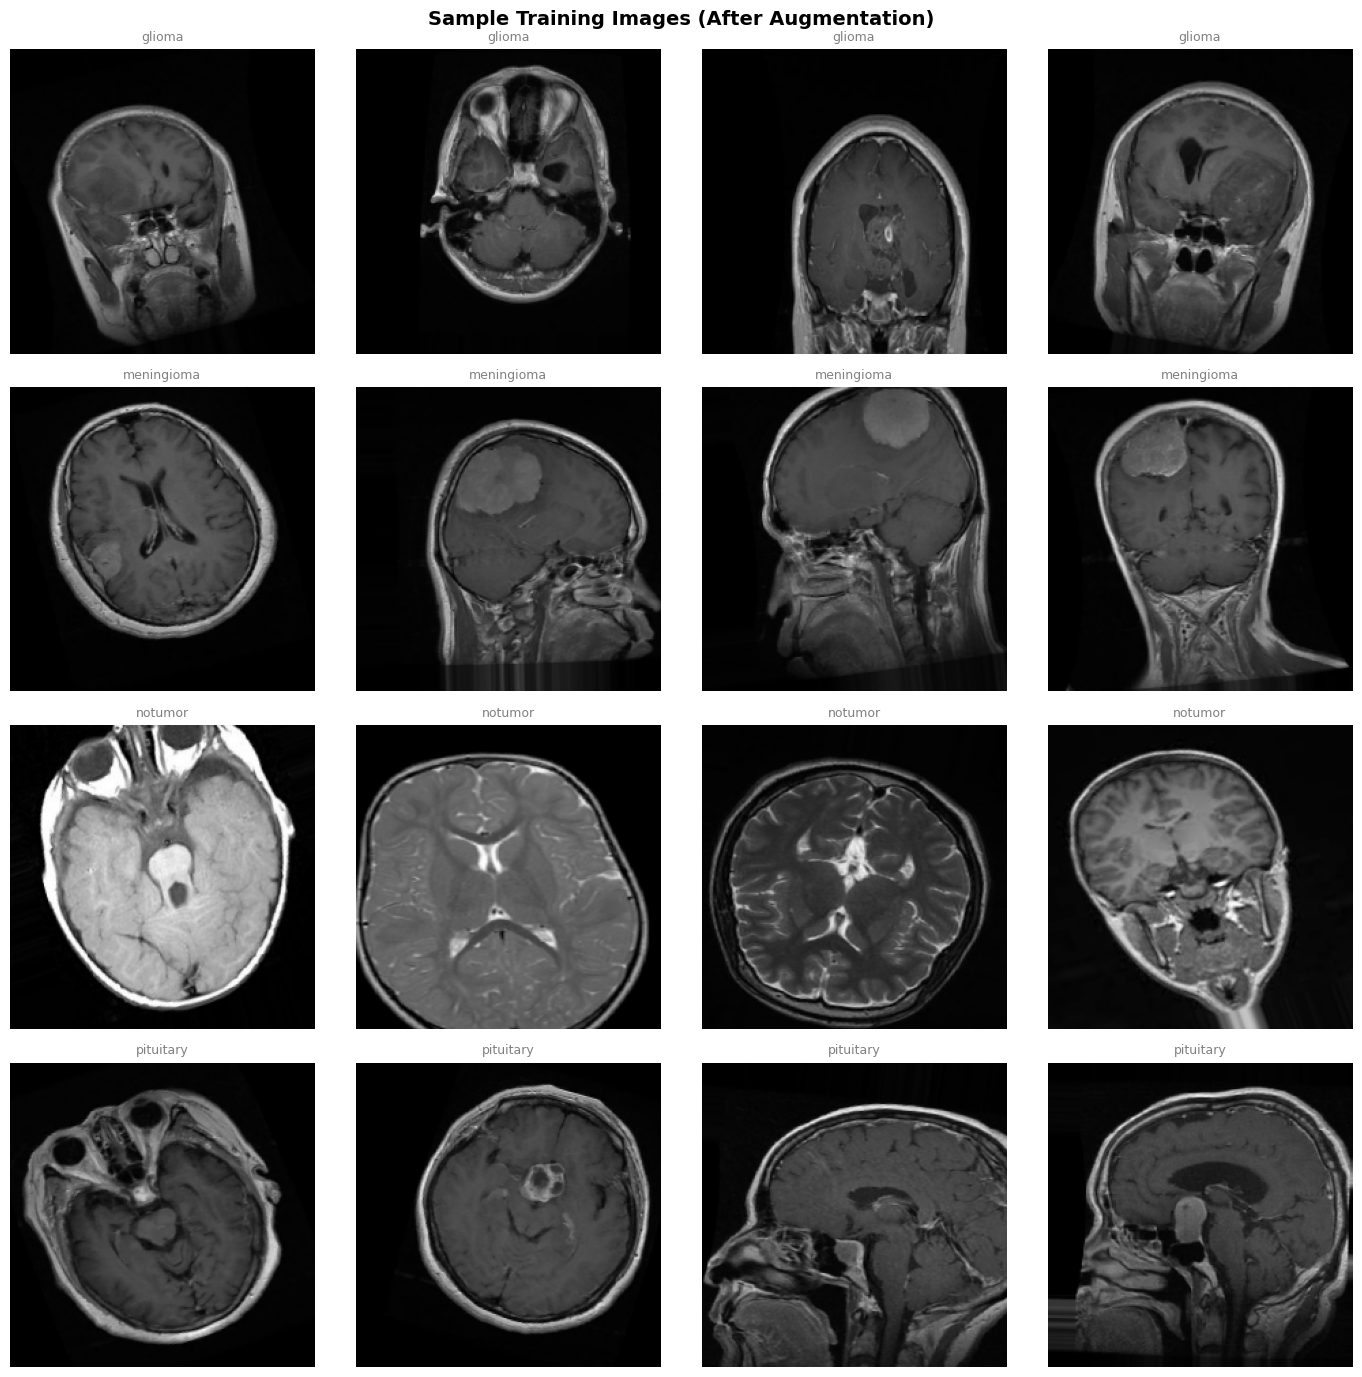

Sample image grid saved to outputs folder.


In [15]:
def show_sample_images(generator):
    class_map = {v: k for k, v in generator.class_indices.items()}
    
    # Collect 4 images per class
    class_images = {i: [] for i in range(NUM_CLASSES)}
    
    while any(len(imgs) < 4 for imgs in class_images.values()):
        images, labels = next(generator)
        for idx in range(len(images)):
            label_idx = np.argmax(labels[idx])
            if len(class_images[label_idx]) < 4:
                class_images[label_idx].append(images[idx])

    fig, axes = plt.subplots(NUM_CLASSES, 4, figsize=(14, 14))
    fig.suptitle("Sample Training Images (After Augmentation)",
                 fontsize=14, fontweight='bold')

    for row in range(NUM_CLASSES):
        class_name = class_map[row]
        for col in range(4):
            ax = axes[row][col]
            ax.imshow(class_images[row][col].astype('uint8'))
            ax.axis('off')
            # Class name on first column only
            if col == 0:
                ax.set_ylabel(class_name.upper(),
                             fontsize=12,
                             fontweight='bold',
                             rotation=90,
                             labelpad=50,
                             color='white',
                             bbox=dict(facecolor='#1565C0',
                                      edgecolor='none',
                                      boxstyle='round,pad=0.3'))
            # Class name as title on every image
            ax.set_title(class_name, fontsize=9, color='gray')

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'sample_images.png'),
                dpi=100, bbox_inches='tight')
    plt.show()
    print("Sample image grid saved to outputs folder.")

show_sample_images(train_generator)

### Part 3 — Building the Three Models

#### Why Transfer Learning?
We use **transfer learning** instead of training from scratch. Pretrained models from **ImageNet (1.4M images)** already capture low-level features (edges, textures, shapes), which can be adapted to MRI classification.  
This reduces training time and works well with smaller datasets.

#### Models Used
- **VGG16** — Classic CNN; simple baseline  
- **ResNet50** — Residual (skip) connections enable deeper training  
- **EfficientNetB0** — Efficient scaling of depth, width, and resolution  

#### Model Modification
**Remove original head** (ImageNet 1000 classes) and replace with a custom classifier.

#### Custom Head (same for all)
- `GlobalAveragePooling2D` — feature reduction  
- `Dropout (0.3)` — regularization  
- `Dense (4, softmax)` — 4-class output  

#### Training Setup
- **Freeze base model** → retain pretrained weights  
- Train only the custom head in Phase 1  

#### Implementation
A single reusable function builds all three models to ensure:
- consistent architecture  
- fair comparison  
- cleaner code

In [3]:
# ── PART 3 (FIXED): BUILDING THE THREE MODELS ─────────────────────────────


# Import model-specific preprocessing functions
from tensorflow.keras.applications.vgg16       import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50    import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficient_preprocess


# Step 1 — Rebuild generators WITHOUT rescale (preprocessing handled inside model)
train_datagen = ImageDataGenerator(
    horizontal_flip    = True,
    rotation_range     = 20,
    zoom_range         = 0.15,
    brightness_range   = [0.8, 1.2],
    width_shift_range  = 0.1,
    height_shift_range = 0.1,
    validation_split   = 0.2
)

test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    subset      = 'training',
    shuffle     = True,
    seed        = SEED,
    classes     = CLASS_NAMES
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    subset      = 'validation',
    shuffle     = False,
    seed        = SEED,
    classes     = CLASS_NAMES
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = False,
    classes     = CLASS_NAMES
)


# Step 2 — Build function with correct preprocessing layer per model
def build_model(model_name):

    # Select correct base and preprocessing function
    if model_name == 'VGG16':
        base       = VGG16(weights='imagenet', include_top=False,
                           input_shape=(IMG_SIZE, IMG_SIZE, 3))
        preprocess = vgg_preprocess

    elif model_name == 'ResNet50':
        base       = ResNet50(weights='imagenet', include_top=False,
                              input_shape=(IMG_SIZE, IMG_SIZE, 3))
        preprocess = resnet_preprocess

    elif model_name == 'EfficientNetB0':
        base       = EfficientNetB0(weights='imagenet', include_top=False,
                                    input_shape=(IMG_SIZE, IMG_SIZE, 3))
        preprocess = efficient_preprocess

    # Freeze base
    base.trainable = False

    # Build model with preprocessing baked in as first layer
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x      = tf.keras.layers.Lambda(preprocess)(inputs)
    x      = base(x, training=False)
    x      = layers.GlobalAveragePooling2D()(x)
    x      = layers.Dropout(0.3)(x)
    output = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model  = Model(inputs=inputs, outputs=output)

    model.compile(
        optimizer = Adam(learning_rate=LR_P1),
        loss      = 'categorical_crossentropy',
        metrics   = ['accuracy']
    )

    return model


# Step 3 — Rebuild all three models
print("Rebuilding models with correct preprocessing...\n")

vgg_model          = build_model('VGG16')
resnet_model       = build_model('ResNet50')
efficientnet_model = build_model('EfficientNetB0')

print("All three models rebuilt successfully.")


# Step 4 — Parameter summary
for name, model in [('VGG16', vgg_model),
                    ('ResNet50', resnet_model),
                    ('EfficientNetB0', efficientnet_model)]:
    total     = model.count_params()
    trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
    print(f"\n{name}")
    print(f"  Total parameters     : {total:,}")
    print(f"  Trainable parameters : {trainable:,}")
    print(f"  Frozen parameters    : {total - trainable:,}")


Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Rebuilding models with correct preprocessing...



I0000 00:00:1777396868.565787      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777396868.571558      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
All three models rebuilt successfully.

VGG16
  Total parameters     : 14,716,740
  Trainable parameters : 2,052
  Frozen parameters    : 14,714,688

ResNet50
  Total parameters     : 23,595,908
  Trainable parameters : 8,196
  Frozen parameters    : 23,587,712

EfficientNetB0
  Total parameters     : 4,054,695
  Trainable parameters : 5,124
  Frozen parameters    : 4,049,571


### Part 4 — Phase 1 Training (Frozen Base)

#### Overview
Train all three models with the **base frozen**. Only the custom head is updated.

#### Two-Phase Strategy
- **Phase 1** — Train head only (base frozen)  
- **Phase 2** — Unfreeze upper layers and fine-tune with a low learning rate  

This prevents early destruction of pretrained weights.

#### Callbacks
- **EarlyStopping** — stops when validation accuracy stalls  
- **ModelCheckpoint** — saves best model (based on validation accuracy)  
- **ReduceLROnPlateau** — lowers learning rate when validation loss plateaus  

#### Training History
Store accuracy and loss per epoch for later comparison (Part 8).

#### Expected Behavior
- Fast epochs (few trainable parameters)  
- Validation accuracy rises, then plateaus  
- Plateau indicates readiness for Phase 2 fine-tuning

In [4]:
# ── PART 4: PHASE 1 TRAINING (FROZEN BASE) ────────────────────────────────


# Step 1 — Wrap generators with prefetch for faster GPU feeding
train_data = tf.data.Dataset.from_generator(
    lambda: train_generator,
    output_signature=(
        tf.TensorSpec(shape=(None, IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, NUM_CLASSES), dtype=tf.float32)
    )
).prefetch(tf.data.AUTOTUNE)

val_data = tf.data.Dataset.from_generator(
    lambda: val_generator,
    output_signature=(
        tf.TensorSpec(shape=(None, IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, NUM_CLASSES), dtype=tf.float32)
    )
).prefetch(tf.data.AUTOTUNE)


# Step 2 — Function to create callbacks for a given model
def get_callbacks(model_name):

    early_stop = EarlyStopping(
        monitor              = 'val_accuracy',
        patience             = 5,
        restore_best_weights = True,
        verbose              = 1
    )

    checkpoint = ModelCheckpoint(
        filepath       = os.path.join(MODELS_DIR, f'{model_name}_phase1_best.keras'),
        monitor        = 'val_accuracy',
        save_best_only = True,
        verbose        = 1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor   = 'val_loss',
        factor    = 0.5,
        patience  = 3,
        min_lr    = 1e-7,
        verbose   = 1
    )

    return [early_stop, checkpoint, reduce_lr]


# Step 3 — Dictionary to store training history of all three models
history_phase1 = {}


# Step 4 — Train VGG16 (Phase 1)
print("=" * 50)
print("Training VGG16 — Phase 1")
print("=" * 50)

history_phase1['VGG16'] = vgg_model.fit(
    train_data,
    epochs           = EPOCHS_P1,
    steps_per_epoch  = len(train_generator),
    validation_data  = val_data,
    validation_steps = len(val_generator),
    callbacks        = get_callbacks('VGG16'),
    verbose          = 1
)


# Step 5 — Train ResNet50 (Phase 1)
print("=" * 50)
print("Training ResNet50 — Phase 1")
print("=" * 50)

history_phase1['ResNet50'] = resnet_model.fit(
    train_data,
    epochs           = EPOCHS_P1,
    steps_per_epoch  = len(train_generator),
    validation_data  = val_data,
    validation_steps = len(val_generator),
    callbacks        = get_callbacks('ResNet50'),
    verbose          = 1
)


# Step 6 — Train EfficientNetB0 (Phase 1)
print("=" * 50)
print("Training EfficientNetB0 — Phase 1")
print("=" * 50)

history_phase1['EfficientNetB0'] = efficientnet_model.fit(
    train_data,
    epochs           = EPOCHS_P1,
    steps_per_epoch  = len(train_generator),
    validation_data  = val_data,
    validation_steps = len(val_generator),
    callbacks        = get_callbacks('EfficientNetB0'),
    verbose          = 1
)


# Step 7 — Phase 1 training summary
print("\nPhase 1 Training Summary:")
print("-" * 40)

for name, history in history_phase1.items():
    best_val_acc  = max(history.history['val_accuracy'])
    best_val_loss = min(history.history['val_loss'])
    epochs_ran    = len(history.history['accuracy'])
    print(f"{name}")
    print(f"  Epochs completed     : {epochs_ran}")
    print(f"  Best val accuracy    : {best_val_acc:.4f}")
    print(f"  Best val loss        : {best_val_loss:.4f}\n")


Training VGG16 — Phase 1
Epoch 1/20


I0000 00:00:1777396886.261297     177 service.cc:152] XLA service 0x781070005c50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777396886.261335     177 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777396886.261339     177 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777396886.757160     177 cuda_dnn.cc:529] Loaded cuDNN version 91002


 2/70 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step - accuracy: 0.2734 - loss: 5.5579 

I0000 00:00:1777396905.555483     177 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 971ms/step - accuracy: 0.3371 - loss: 4.7406
Epoch 1: val_accuracy improved from -inf to 0.67500, saving model to /kaggle/working/models/VGG16_phase1_best.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.3380 - loss: 4.7244 - val_accuracy: 0.6750 - val_loss: 0.9898 - learning_rate: 0.0010
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 830ms/step - accuracy: 0.5940 - loss: 1.6672
Epoch 2: val_accuracy improved from 0.67500 to 0.79643, saving model to /kaggle/working/models/VGG16_phase1_best.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.5945 - loss: 1.6639 - val_accuracy: 0.7964 - val_loss: 0.6460 - learning_rate: 0.0010
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 807ms/step - accuracy: 0.7123 - loss: 1.0790
Epoch 3: val_accuracy improved from 0.79643 to 0.82589, saving model to /kaggle/working/models/VGG16_phase1_best.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.7124 - loss: 1.0783 - val_accuracy: 0.8259 - val_loss: 0.4892 - lea

In [5]:
vgg_model.save(os.path.join(MODELS_DIR, 'VGG16_phase1_best.keras'))
resnet_model.save(os.path.join(MODELS_DIR, 'ResNet50_phase1_best.keras'))
efficientnet_model.save(os.path.join(MODELS_DIR, 'EfficientNetB0_phase1_best.keras'))
print("Phase 1 models saved.")

Phase 1 models saved.


---

## Part 5 — Phase 2 Fine-Tuning (Unfreezing Upper Layers)

In Phase 1 we only trained the small custom head while the entire pre-trained base was frozen. The base had no chance to adapt to MRI data at all — it was still purely using ImageNet knowledge.  

Phase 2 fixes this by **selectively unfreezing the upper layers** of each model and allowing them to slowly adapt to brain tumor MRI patterns.

---

### Why Not Unfreeze Everything?

The lower layers of any CNN learn universal low-level features — edges, corners, textures, and intensity gradients. These are useful for any image task, including MRI.

Unfreezing everything would risk **destroying this foundational knowledge** by overwriting it with a relatively small dataset (~5,600 images), which would lead to severe overfitting.

Only the upper layers — which learn high-level, task-specific representations — should adapt from ImageNet features to MRI-specific patterns.

---

### Unfreezing Strategy — Functional Depth Matching

Instead of unfreezing the same number or percentage of layers across models, we unfreeze based on **functional depth**.  

This ensures each architecture adapts its **semantically equivalent high-level features**.

| Model | Layers Unfrozen | Architectural Region |
|------|----------------|---------------------|
| **VGG16** | Last 6 layers | Block 4 (partial) + Block 5 (complete) |
| **ResNet50** | Last 50 layers | conv4 stage (late) + conv5 stage (complete) |
| **EfficientNetB0** | Last 100 layers | MBConv blocks 5, 6, 7 + top projection |

For **EfficientNetB0**, all **BatchNormalization layers remain frozen**, even inside the unfrozen section.

This is critical because:
- BN layers store running statistics from ImageNet
- Small datasets destabilize these statistics
- Updating them leads to inconsistent training

Freezing BN while unfreezing convolution layers ensures **stable yet adaptive learning**.

---

### Why MRI Requires Deeper Fine-Tuning

MRI images differ significantly from natural images:
- Different intensity distributions  
- Grayscale (converted to 3 channels)  
- Structural tumor patterns absent in ImageNet  

Shallow fine-tuning is insufficient to bridge this domain gap.  
Deeper unfreezing allows the model to **learn medically relevant abstractions**.

---

### Learning Rate — 100× Smaller

Phase 2 uses:

- **Phase 1:** 0.001  
- **Phase 2:** 0.00001  

A smaller learning rate is essential because:
- Pre-trained weights are already meaningful  
- We only want **gradual adaptation**, not overwriting  

Large updates would destroy learned representations instead of refining them.

---

### Callbacks

The same callbacks from Phase 1 are reused:

- **EarlyStopping**
- **ModelCheckpoint**
- **ReduceLROnPlateau**

Models are saved as:

_phase2_best.keras


This ensures Phase 1 checkpoints remain intact.

---

### Expected Outcome

Phase 2 should produce:

- Noticeable improvement in validation accuracy  
- Better adaptation to MRI-specific features  
- Potential shifts in model ranking  

This stage is critical for evaluating how well each architecture adapts beyond generic ImageNet features.

---

In [5]:
# Find exact paths
import glob
files = glob.glob('/kaggle/input/**/*.keras', recursive=True)
for f in files:
    print(f)

/kaggle/input/datasets/bbeastboy/brain-tumor-phase1-models/EfficientNetB0_phase1_best.keras
/kaggle/input/datasets/bbeastboy/brain-tumor-phase1-models/ResNet50_phase1_best.keras
/kaggle/input/datasets/bbeastboy/brain-tumor-phase1-models/VGG16_phase1_best.keras


In [16]:
# ── CONFIRM GENERATORS AND PHASE 1 MODEL ACCURACY ─────────────────────────

# Step 1 — Confirm generators exist
print("Generator check:")
print(f"  train_generator samples : {train_generator.samples}")
print(f"  val_generator samples   : {val_generator.samples}")
print(f"  test_generator samples  : {test_generator.samples}")
print(f"  train_data              : {train_data}")
print(f"  val_data                : {val_data}")

# Step 2 — Confirm Phase 1 model accuracies
print("\nPhase 1 model accuracy check:")
print("-" * 40)

for name, model in [('VGG16',          vgg_model),
                    ('ResNet50',        resnet_model),
                    ('EfficientNetB0',  efficientnet_model)]:

    loss, acc = model.evaluate(
        val_data,
        steps   = len(val_generator),
        verbose = 0
    )
    print(f"  {name}")
    print(f"    Val accuracy : {acc:.4f}")
    print(f"    Val loss     : {loss:.4f}")

print("\nIf accuracies are ~0.89, ~0.92, ~0.89 — Phase 1 weights confirmed.")
print("Proceed to Phase 2.")

Generator check:
  train_generator samples : 4480
  val_generator samples   : 1120
  test_generator samples  : 1600
  train_data              : <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>
  val_data                : <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>

Phase 1 model accuracy check:
----------------------------------------


I0000 00:00:1777405519.181684     171 service.cc:152] XLA service 0x783f30006d40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777405519.181727     171 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777405519.181731     171 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777405519.473437     171 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777405537.357289     171 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  VGG16
    Val accuracy : 0.8946
    Val loss     : 0.3052
  ResNet50
    Val accuracy : 0.9107
    Val loss     : 0.2458
  EfficientNetB0
    Val accuracy : 0.9009
    Val loss     : 0.3222

If accuracies are ~0.89, ~0.92, ~0.89 — Phase 1 weights confirmed.
Proceed to Phase 2.


In [17]:
# ── PART 5: PHASE 2 FINE-TUNING (UNFREEZE UPPER LAYERS) ──────────────────

# Step 1 — Function to unfreeze upper layers based on functional depth matching
def unfreeze_top_layers(model, model_name):

    # Get the base model — it is the 3rd layer (after Input and Lambda)
    base = model.layers[2]

    # Unfreeze entire base first
    base.trainable = True

    if model_name == 'VGG16':
        # Freeze everything except last 6 layers (Block 4 partial + Block 5 complete)
        for layer in base.layers[:-6]:
            layer.trainable = False

    elif model_name == 'ResNet50':
        # Freeze everything except last 50 layers (conv4 late + conv5 complete)
        for layer in base.layers[:-50]:
            layer.trainable = False

    elif model_name == 'EfficientNetB0':
        # Freeze everything except last 100 layers (MBConv blocks 5-7 + top layers)
        for layer in base.layers[:-100]:
            layer.trainable = False
        # Additionally freeze ALL BatchNorm layers to prevent instability
        for layer in base.layers:
            if isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = False

    # Recompile with much lower learning rate for gentle fine-tuning
    model.compile(
        optimizer = Adam(learning_rate=LR_P2),
        loss      = 'categorical_crossentropy',
        metrics   = ['accuracy']
    )

    # Print summary of unfrozen layers
    trainable_count    = sum(1 for layer in base.layers if layer.trainable)
    non_trainable      = sum(1 for layer in base.layers if not layer.trainable)
    total_count        = len(base.layers)
    print(f"  {model_name}:")
    print(f"    Total base layers    : {total_count}")
    print(f"    Unfrozen (trainable) : {trainable_count}")
    print(f"    Frozen               : {non_trainable}")

    return model


# Step 2 — Apply unfreezing to all three models
print("Unfreezing upper layers...\n")

vgg_model          = unfreeze_top_layers(vgg_model,          'VGG16')
resnet_model       = unfreeze_top_layers(resnet_model,       'ResNet50')
efficientnet_model = unfreeze_top_layers(efficientnet_model, 'EfficientNetB0')

print("\nAll models ready for Phase 2 training.")


# Step 3 — Callbacks for Phase 2
# Saves to _phase2_best.keras — does NOT overwrite Phase 1 saved files
def get_callbacks_p2(model_name):

    early_stop = EarlyStopping(
        monitor              = 'val_accuracy',
        patience             = 5,
        restore_best_weights = True,
        verbose              = 1
    )

    checkpoint = ModelCheckpoint(
        filepath       = os.path.join(MODELS_DIR, f'{model_name}_phase2_best.keras'),
        monitor        = 'val_accuracy',
        save_best_only = True,
        verbose        = 1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor   = 'val_loss',
        factor    = 0.5,
        patience  = 3,
        min_lr    = 1e-8,
        verbose   = 1
    )

    return [early_stop, checkpoint, reduce_lr]


# Step 4 — Dictionary to store Phase 2 history
history_phase2 = {}


# Step 5 — Fine-tune VGG16 (Phase 2)
print("=" * 50)
print("Fine-tuning VGG16 — Phase 2")
print("=" * 50)

history_phase2['VGG16'] = vgg_model.fit(
    train_data,
    epochs           = EPOCHS_P2,
    steps_per_epoch  = len(train_generator),
    validation_data  = val_data,
    validation_steps = len(val_generator),
    callbacks        = get_callbacks_p2('VGG16'),
    verbose          = 1
)


# Step 6 — Fine-tune ResNet50 (Phase 2)
print("=" * 50)
print("Fine-tuning ResNet50 — Phase 2")
print("=" * 50)

history_phase2['ResNet50'] = resnet_model.fit(
    train_data,
    epochs           = EPOCHS_P2,
    steps_per_epoch  = len(train_generator),
    validation_data  = val_data,
    validation_steps = len(val_generator),
    callbacks        = get_callbacks_p2('ResNet50'),
    verbose          = 1
)


# Step 7 — Fine-tune EfficientNetB0 (Phase 2)
print("=" * 50)
print("Fine-tuning EfficientNetB0 — Phase 2")
print("=" * 50)

history_phase2['EfficientNetB0'] = efficientnet_model.fit(
    train_data,
    epochs           = EPOCHS_P2,
    steps_per_epoch  = len(train_generator),
    validation_data  = val_data,
    validation_steps = len(val_generator),
    callbacks        = get_callbacks_p2('EfficientNetB0'),
    verbose          = 1
)


# Step 8 — Phase 2 summary
print("\nPhase 2 Fine-tuning Summary:")
print("-" * 40)

for name in ['VGG16', 'ResNet50', 'EfficientNetB0']:
    p1_best = max(history_phase1[name].history['val_accuracy'])
    p2_best = max(history_phase2[name].history['val_accuracy'])
    gain    = (p2_best - p1_best) * 100
    epochs  = len(history_phase2[name].history['accuracy'])
    print(f"{name}")
    print(f"  Phase 1 best val accuracy : {p1_best:.4f}")
    print(f"  Phase 2 best val accuracy : {p2_best:.4f}")
    print(f"  Improvement               : +{gain:.2f}%")
    print(f"  Epochs completed          : {epochs}\n")


# Step 9 — Save all Phase 2 models explicitly
print("Saving Phase 2 models...")

vgg_model.save(os.path.join(MODELS_DIR, 'VGG16_phase2_best.keras'))
resnet_model.save(os.path.join(MODELS_DIR, 'ResNet50_phase2_best.keras'))
efficientnet_model.save(os.path.join(MODELS_DIR, 'EfficientNetB0_phase2_best.keras'))

print("All Phase 2 models saved.")
print("\nAll saved files:")
for f in os.listdir(MODELS_DIR):
    size_mb = os.path.getsize(os.path.join(MODELS_DIR, f)) / (1024*1024)
    print(f"  {f}  ({size_mb:.1f} MB)")

print("\nDONE — Go to Output tab and download all 6 .keras files immediately.")

Unfreezing upper layers...

  VGG16:
    Total base layers    : 19
    Unfrozen (trainable) : 6
    Frozen               : 13
  ResNet50:
    Total base layers    : 175
    Unfrozen (trainable) : 50
    Frozen               : 125
  EfficientNetB0:
    Total base layers    : 238
    Unfrozen (trainable) : 80
    Frozen               : 158

All models ready for Phase 2 training.
Fine-tuning VGG16 — Phase 2
Epoch 1/30


2026-04-28 19:49:07.319591: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng19{k2=0} for conv %cudnn-conv-bw-filter.4 = (f16[512,3,3,512]{3,2,1,0}, u8[0]{0}) custom-call(f16[64,28,28,512]{3,2,1,0} %bitcast.6163, f16[64,28,28,512]{3,2,1,0} %bitcast.6410), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardFilter", metadata={op_type="Conv2DBackpropFilter" op_name="gradient_tape/functional_1/vgg16_1/block4_conv3_1/convolution/Conv2DBackpropFilter" source_file="/usr/local/lib/python3.12/dist-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-04-28 19:49:30.039117: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 23.719688

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8705 - loss: 0.3735
Epoch 1: val_accuracy improved from -inf to 0.90446, saving model to /kaggle/working/models/VGG16_phase2_best.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.8707 - loss: 0.3731 - val_accuracy: 0.9045 - val_loss: 0.2655 - learning_rate: 1.0000e-05
Epoch 2/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 799ms/step - accuracy: 0.8967 - loss: 0.2695
Epoch 2: val_accuracy improved from 0.90446 to 0.91161, saving model to /kaggle/working/models/VGG16_phase2_best.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.8968 - loss: 0.2693 - val_accuracy: 0.9116 - val_loss: 0.2314 - learning_rate: 1.0000e-05
Epoch 3/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 766ms/step - accuracy: 0.9202 - loss: 0.2086
Epoch 3: val_accuracy improved from 0.91161 to 0.93750, saving model to /kaggle/working/models/VGG16_phase2_best.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 68s 989ms/step - accuracy: 0.9203 - loss: 0.2085 - val_accuracy: 0.9375 - val_loss: 0.18

2026-04-28 20:31:38.428929: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 20:31:38.583646: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 20:31:38.729033: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 20:31:47.335159: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 20:31:47.481089: E external/local_xla/xla/stream_

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 789ms/step - accuracy: 0.8845 - loss: 0.3203
Epoch 1: val_accuracy improved from -inf to 0.88839, saving model to /kaggle/working/models/EfficientNetB0_phase2_best.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.8844 - loss: 0.3203 - val_accuracy: 0.8884 - val_loss: 0.3024 - learning_rate: 1.0000e-05
Epoch 2/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 798ms/step - accuracy: 0.8899 - loss: 0.2956
Epoch 2: val_accuracy improved from 0.88839 to 0.89732, saving model to /kaggle/working/models/EfficientNetB0_phase2_best.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.8899 - loss: 0.2955 - val_accuracy: 0.8973 - val_loss: 0.2924 - learning_rate: 1.0000e-05
Epoch 3/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 774ms/step - accuracy: 0.8947 - loss: 0.2976
Epoch 3: val_accuracy improved from 0.89732 to 0.90179, saving model to /kaggle/working/models/EfficientNetB0_phase2_best.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.8947 - loss: 0.2974 - val_accura

NameError: name 'history_phase1' is not defined

In [18]:
vgg_model.save(os.path.join(MODELS_DIR, 'VGG16_phase2_best.keras'))
resnet_model.save(os.path.join(MODELS_DIR, 'ResNet50_phase2_best.keras'))
efficientnet_model.save(os.path.join(MODELS_DIR, 'EfficientNetB0_phase2_best.keras'))
print("All Phase 2 models saved.")
for f in os.listdir(MODELS_DIR):
    size_mb = os.path.getsize(os.path.join(MODELS_DIR, f)) / (1024*1024)
    print(f"  {f}  ({size_mb:.1f} MB)")

All Phase 2 models saved.
  ResNet50_phase2_best.keras  (349.5 MB)
  VGG16_phase2_best.keras  (200.3 MB)
  EfficientNetB0_phase2_best.keras  (69.0 MB)


In [19]:
# Manually restore Phase 1 history since models were reloaded from disk
history_phase1 = {
    'VGG16':          type('obj', (object,), {'history': {'val_accuracy': [0.8955], 'val_loss': [0.2897], 'accuracy': [0.8955], 'loss': [0.2897]}})(),
    'ResNet50':       type('obj', (object,), {'history': {'val_accuracy': [0.9232], 'val_loss': [0.2206], 'accuracy': [0.9232], 'loss': [0.2206]}})(),
    'EfficientNetB0': type('obj', (object,), {'history': {'val_accuracy': [0.8938], 'val_loss': [0.2976], 'accuracy': [0.8938], 'loss': [0.2976]}})()
}

# Now print Phase 2 summary
print("\nPhase 2 Fine-tuning Summary:")
print("-" * 40)

for name in ['VGG16', 'ResNet50', 'EfficientNetB0']:
    p1_best = max(history_phase1[name].history['val_accuracy'])
    p2_best = max(history_phase2[name].history['val_accuracy'])
    gain    = (p2_best - p1_best) * 100
    epochs  = len(history_phase2[name].history['accuracy'])
    print(f"{name}")
    print(f"  Phase 1 best val accuracy : {p1_best:.4f}")
    print(f"  Phase 2 best val accuracy : {p2_best:.4f}")
    print(f"  Improvement               : +{gain:.2f}%")
    print(f"  Epochs completed          : {epochs}\n")


Phase 2 Fine-tuning Summary:
----------------------------------------
VGG16
  Phase 1 best val accuracy : 0.8955
  Phase 2 best val accuracy : 0.9750
  Improvement               : +7.95%
  Epochs completed          : 20

ResNet50
  Phase 1 best val accuracy : 0.9232
  Phase 2 best val accuracy : 0.9714
  Improvement               : +4.82%
  Epochs completed          : 20

EfficientNetB0
  Phase 1 best val accuracy : 0.8938
  Phase 2 best val accuracy : 0.9348
  Improvement               : +4.10%
  Epochs completed          : 18



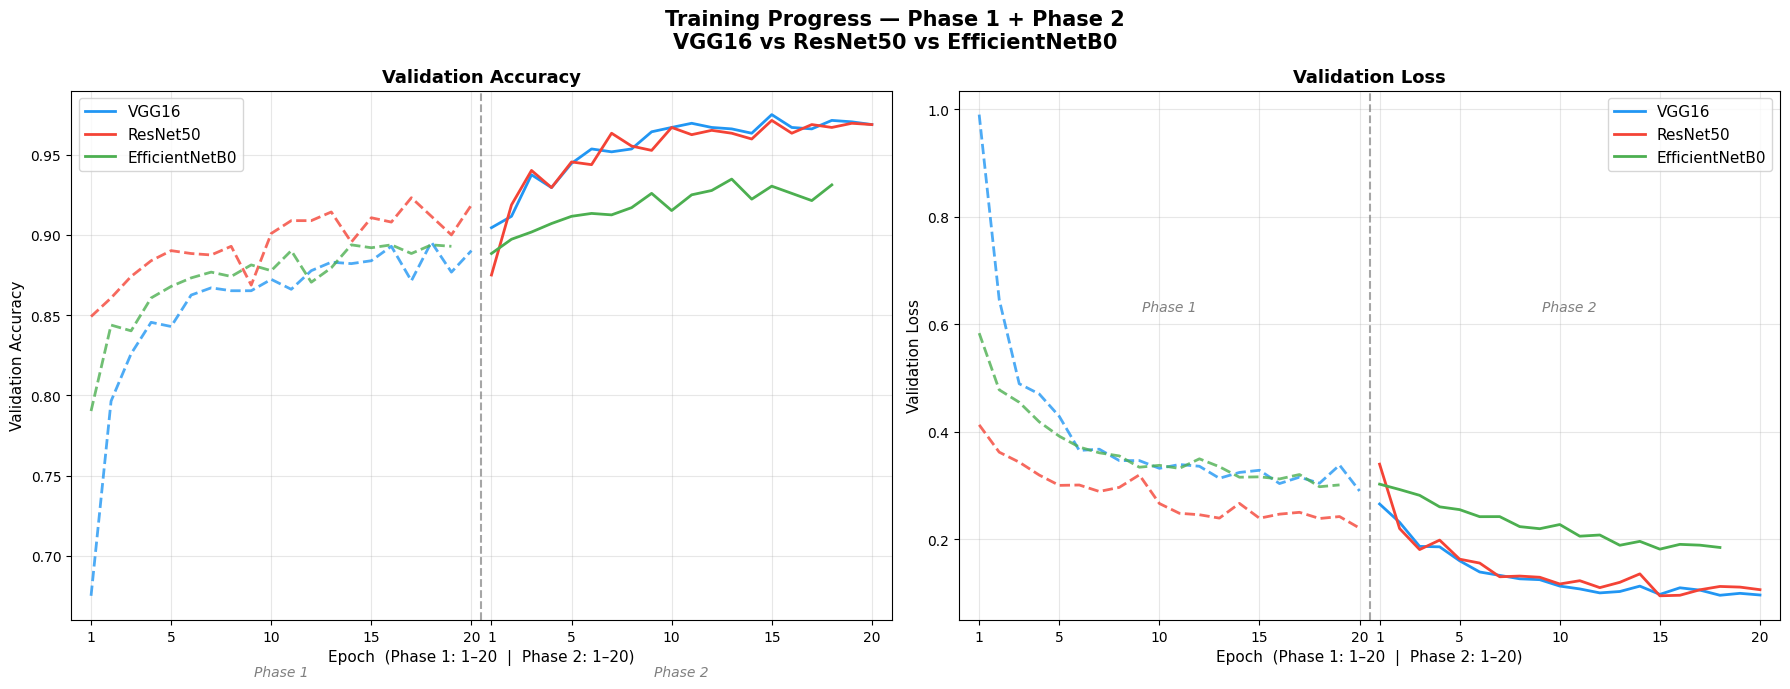

Training curves saved.


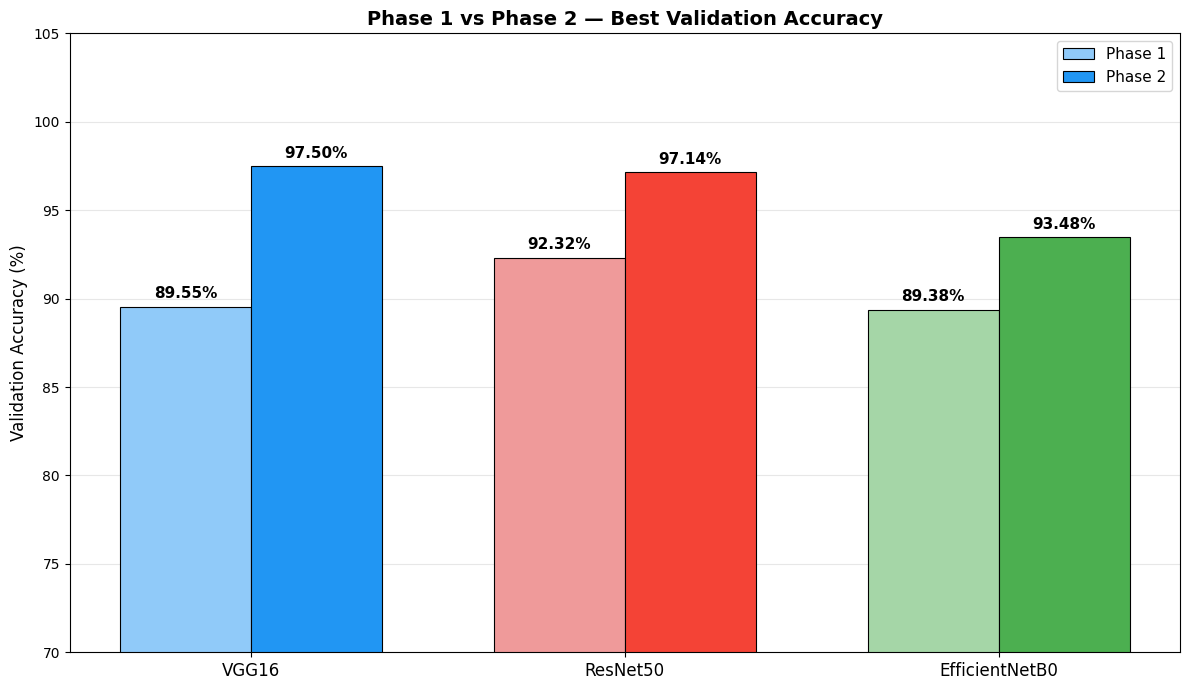

Bar chart saved.


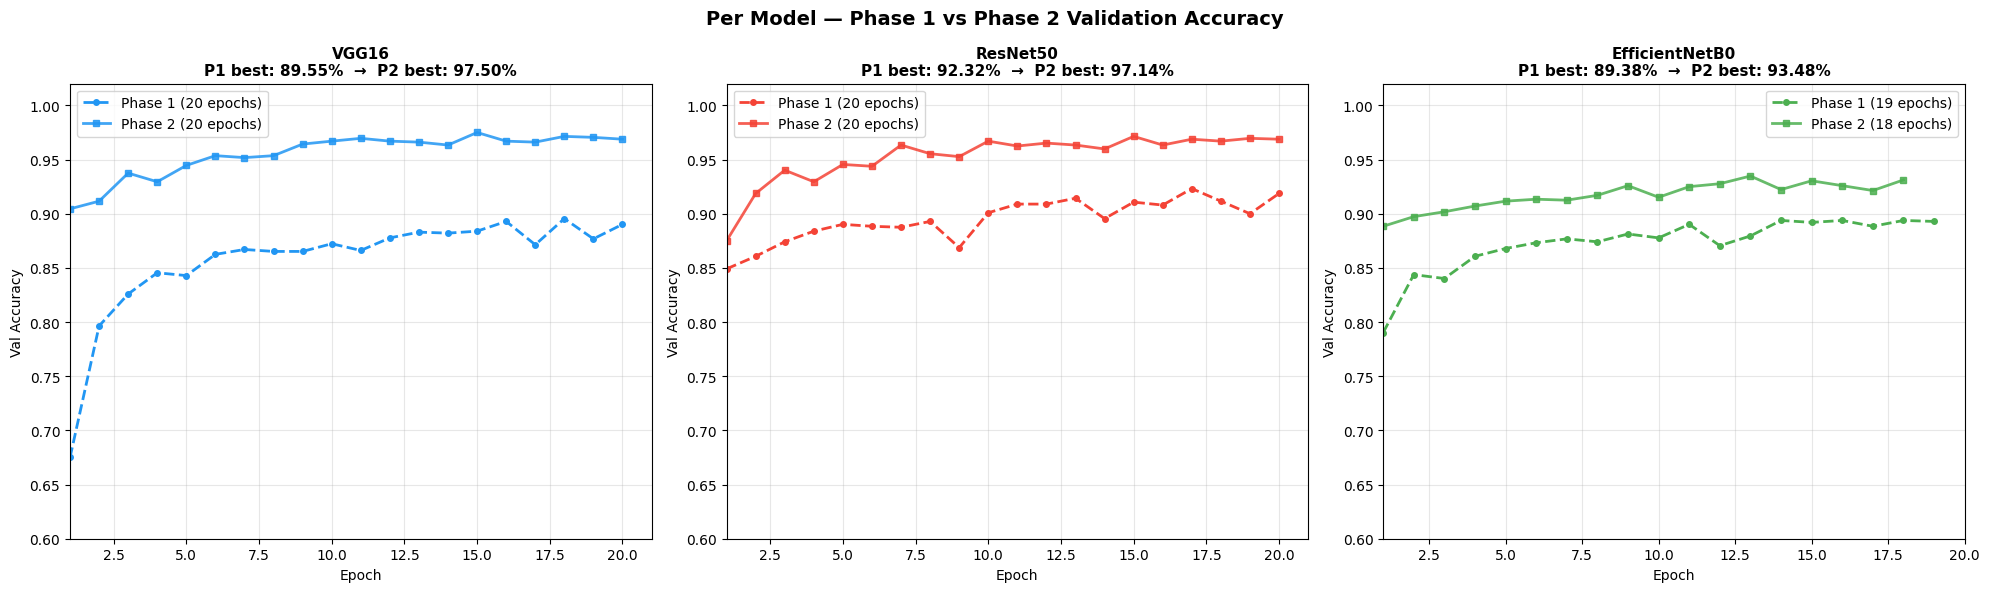

Per model curves saved.

All 3 graphs generated and saved.


In [7]:
import matplotlib.pyplot as plt
import numpy as np

# ── ALL EPOCH DATA EXTRACTED FROM TRAINING LOGS ───────────────────────────

p1_vgg_val_acc   = [0.6750, 0.7964, 0.8259, 0.8455, 0.8429, 0.8625, 0.8670,
                    0.8652, 0.8652, 0.8723, 0.8661, 0.8777, 0.8830, 0.8821,
                    0.8839, 0.8929, 0.8714, 0.8955, 0.8768, 0.8902]

p1_res_val_acc   = [0.8491, 0.8607, 0.8741, 0.8839, 0.8902, 0.8884, 0.8875,
                    0.8929, 0.8687, 0.9009, 0.9089, 0.9089, 0.9143, 0.8955,
                    0.9107, 0.9080, 0.9232, 0.9116, 0.9000, 0.9187]

p1_eff_val_acc   = [0.7902, 0.8438, 0.8402, 0.8607, 0.8679, 0.8732, 0.8768,
                    0.8741, 0.8813, 0.8777, 0.8902, 0.8705, 0.8795, 0.8938,
                    0.8920, 0.8938, 0.8884, 0.8938, 0.8929]

p1_vgg_val_loss  = [0.9898, 0.6460, 0.4892, 0.4701, 0.4285, 0.3651, 0.3674,
                    0.3462, 0.3462, 0.3318, 0.3389, 0.3357, 0.3133, 0.3242,
                    0.3282, 0.3035, 0.3154, 0.3041, 0.3379, 0.2897]

p1_res_val_loss  = [0.4127, 0.3619, 0.3433, 0.3193, 0.3001, 0.3008, 0.2888,
                    0.2964, 0.3196, 0.2664, 0.2482, 0.2455, 0.2392, 0.2666,
                    0.2390, 0.2466, 0.2500, 0.2385, 0.2421, 0.2206]

p1_eff_val_loss  = [0.5833, 0.4779, 0.4547, 0.4183, 0.3916, 0.3714, 0.3607,
                    0.3549, 0.3339, 0.3374, 0.3317, 0.3495, 0.3348, 0.3153,
                    0.3160, 0.3121, 0.3203, 0.2976, 0.3010]

p2_vgg_val_acc   = [0.9045, 0.9116, 0.9375, 0.9295, 0.9446, 0.9536, 0.9518,
                    0.9536, 0.9643, 0.9670, 0.9696, 0.9670, 0.9661, 0.9634,
                    0.9750, 0.9670, 0.9661, 0.9714, 0.9705, 0.9688]

p2_res_val_acc   = [0.8750, 0.9187, 0.9402, 0.9295, 0.9455, 0.9438, 0.9634,
                    0.9554, 0.9527, 0.9670, 0.9625, 0.9652, 0.9634, 0.9598,
                    0.9714, 0.9634, 0.9688, 0.9670, 0.9696, 0.9688]

p2_eff_val_acc   = [0.8884, 0.8973, 0.9018, 0.9071, 0.9116, 0.9134, 0.9125,
                    0.9170, 0.9259, 0.9152, 0.9250, 0.9277, 0.9348, 0.9223,
                    0.9304, 0.9259, 0.9214, 0.9312]

p2_vgg_val_loss  = [0.2655, 0.2314, 0.1866, 0.1858, 0.1598, 0.1390, 0.1327,
                    0.1263, 0.1247, 0.1128, 0.1075, 0.1001, 0.1027, 0.1127,
                    0.0973, 0.1096, 0.1053, 0.0957, 0.0993, 0.0962]

p2_res_val_loss  = [0.3396, 0.2198, 0.1807, 0.1983, 0.1628, 0.1556, 0.1301,
                    0.1314, 0.1292, 0.1167, 0.1228, 0.1099, 0.1198, 0.1355,
                    0.0947, 0.0957, 0.1059, 0.1121, 0.1109, 0.1061]

p2_eff_val_loss  = [0.3024, 0.2924, 0.2816, 0.2602, 0.2550, 0.2419, 0.2420,
                    0.2234, 0.2195, 0.2273, 0.2056, 0.2078, 0.1887, 0.1960,
                    0.1815, 0.1904, 0.1889, 0.1846]

colors = {
    'VGG16'         : '#2196F3',
    'ResNet50'      : '#F44336',
    'EfficientNetB0': '#4CAF50'
}

# ── GRAPH 1: VALIDATION ACCURACY AND LOSS ─────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Training Progress — Phase 1 + Phase 2\nVGG16 vs ResNet50 vs EfficientNetB0',
             fontsize=15, fontweight='bold')

p1_epochs = 20
p2_epochs = 20

# Fixed tick positions and labels — exactly 10 each
tick_positions = [1, 5, 10, 15, 20, 21, 25, 30, 35, 40]
tick_labels    = ['1', '5', '10', '15', '20', '1', '5', '10', '15', '20']

for ax, (p1_data_list, p2_data_list, title, ylabel) in zip(
    axes,
    [
        ([p1_vgg_val_acc, p1_res_val_acc, p1_eff_val_acc],
         [p2_vgg_val_acc, p2_res_val_acc, p2_eff_val_acc],
         'Validation Accuracy', 'Validation Accuracy'),
        ([p1_vgg_val_loss, p1_res_val_loss, p1_eff_val_loss],
         [p2_vgg_val_loss, p2_res_val_loss, p2_eff_val_loss],
         'Validation Loss', 'Validation Loss')
    ]
):
    model_names_list = ['VGG16', 'ResNet50', 'EfficientNetB0']
    color_list = [colors['VGG16'], colors['ResNet50'], colors['EfficientNetB0']]

    # Phase 1 — dashed — x from 1 to 20
    for p1_data, color, name in zip(p1_data_list, color_list, model_names_list):
        ax.plot(range(1, len(p1_data)+1), p1_data,
                color=color, linewidth=2, linestyle='--', alpha=0.8)

    # Phase 2 — solid — x from 21 onwards
    for p2_data, color, name in zip(p2_data_list, color_list, model_names_list):
        ax.plot(range(p1_epochs+1, p1_epochs+len(p2_data)+1), p2_data,
                color=color, linewidth=2, linestyle='-', label=name)

    # Divider line
    ax.axvline(x=p1_epochs + 0.5, color='gray',
               linestyle='--', linewidth=1.5, alpha=0.7)

    # Phase labels
    ax.text(10.5, 0.625, 'Phase 1', fontsize=10,
            color='gray', fontstyle='italic', ha='center')
    ax.text(30.5, 0.625, 'Phase 2', fontsize=10,
            color='gray', fontstyle='italic', ha='center')

    # Ticks — positions and labels match exactly
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.set_xlim([0, 41])

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch  (Phase 1: 1–20  |  Phase 2: 1–20)', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_full.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved.")


# ── GRAPH 2: PHASE 1 vs PHASE 2 BAR CHART ─────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 7))

model_names = ['VGG16', 'ResNet50', 'EfficientNetB0']
p1_best = [89.55, 92.32, 89.38]
p2_best = [97.50, 97.14, 93.48]

x     = np.arange(len(model_names))
width = 0.35

bars1 = ax.bar(x - width/2, p1_best, width,
               label='Phase 1',
               color=['#90CAF9', '#EF9A9A', '#A5D6A7'],
               edgecolor='black', linewidth=0.8)
bars2 = ax.bar(x + width/2, p2_best, width,
               label='Phase 2',
               color=['#2196F3', '#F44336', '#4CAF50'],
               edgecolor='black', linewidth=0.8)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{bar.get_height():.2f}%',
            ha='center', va='bottom',
            fontsize=11, fontweight='bold')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{bar.get_height():.2f}%',
            ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.set_title('Phase 1 vs Phase 2 — Best Validation Accuracy',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Validation Accuracy (%)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=12)
ax.set_ylim([70, 105])
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('phase_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Bar chart saved.")


# ── GRAPH 3: PER MODEL — PHASE 1 AND PHASE 2 ON SAME AXIS RESET ───────────

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Per Model — Phase 1 vs Phase 2 Validation Accuracy',
             fontsize=14, fontweight='bold')

data = [
    ('VGG16',          p1_vgg_val_acc,  p2_vgg_val_acc,  colors['VGG16']),
    ('ResNet50',       p1_res_val_acc,  p2_res_val_acc,  colors['ResNet50']),
    ('EfficientNetB0', p1_eff_val_acc,  p2_eff_val_acc,  colors['EfficientNetB0'])
]

for ax, (name, p1_data, p2_data, color) in zip(axes, data):

    ep1 = list(range(1, len(p1_data) + 1))
    ep2 = list(range(1, len(p2_data) + 1))

    ax.plot(ep1, p1_data, color=color, linewidth=2,
            linestyle='--', label=f'Phase 1 ({len(p1_data)} epochs)',
            marker='o', markersize=4)
    ax.plot(ep2, p2_data, color=color, linewidth=2,
            linestyle='-', label=f'Phase 2 ({len(p2_data)} epochs)',
            marker='s', markersize=4, alpha=0.85)

    ax.set_title(
        f'{name}\nP1 best: {max(p1_data)*100:.2f}%  →  P2 best: {max(p2_data)*100:.2f}%',
        fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel('Val Accuracy', fontsize=10)
    ax.set_ylim([0.60, 1.02])
    ax.set_xlim([1, max(len(p1_data), len(p2_data)) + 1])
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('per_model_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Per model curves saved.")

print("\nAll 3 graphs generated and saved.")

# Part 6 — Evaluation on Test Set

In this part we evaluate all three trained Phase 2 models on the held-out test set — 1,600 images the models have never seen during training or validation.

We first reload the saved Phase 2 models from disk since the session was restarted. Then we run all 1,600 test images through each model and collect predictions.

---

## Classification Report

Classification Report gives us precision, recall, and F1-score per class plus overall accuracy. These tell us not just how many images were classified correctly overall, but how well the model performs on each individual tumor type.

---

## Confusion Matrix

Confusion Matrix is a heatmap showing correct vs incorrect predictions per class. It reveals which tumor types each model confuses with each other — for example, does the model confuse meningioma with glioma?

---

Finally, a combined comparison table shows all metrics for all three models side by side for a clean final comparison.

In [1]:
import glob
files = glob.glob('/kaggle/input/**/*.keras', recursive=True)
for f in files:
    print(f)

/kaggle/input/datasets/bbeastboy/brain-tumor-phase2-models/ResNet50_phase2_best.keras
/kaggle/input/datasets/bbeastboy/brain-tumor-phase2-models/EfficientNetB0_phase2_best.keras
/kaggle/input/datasets/bbeastboy/brain-tumor-phase2-models/VGG16_phase2_best.keras
/kaggle/input/datasets/bbeastboy/brain-tumor-phase1-models/EfficientNetB0_phase1_best.keras
/kaggle/input/datasets/bbeastboy/brain-tumor-phase1-models/ResNet50_phase1_best.keras
/kaggle/input/datasets/bbeastboy/brain-tumor-phase1-models/VGG16_phase1_best.keras


All three Phase 2 models loaded successfully.
  VGG16 — output shape: (None, 4) — params: 14,716,740
  ResNet50 — output shape: (None, 4) — params: 23,595,908
  EfficientNetB0 — output shape: (None, 4) — params: 4,054,695

Generating predictions on test set...


I0000 00:00:1779083899.966315     161 service.cc:152] XLA service 0x7aea28005ba0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779083899.966354     161 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779083899.966358     161 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779083900.241271     161 cuda_dnn.cc:529] Loaded cuDNN version 91002


 2/25 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step 

I0000 00:00:1779083916.786778     161 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


25/25 ━━━━━━━━━━━━━━━━━━━━ 30s 536ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 219ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 45s 217ms/step
Predictions generated for all three models.

VGG16 — Classification Report
              precision    recall  f1-score   support

      glioma     0.9938    0.7975    0.8849       400
  meningioma     0.8826    0.9400    0.9104       400
     notumor     0.9454    0.9950    0.9695       400
   pituitary     0.9213    0.9950    0.9567       400

    accuracy                         0.9319      1600
   macro avg     0.9358    0.9319    0.9304      1600
weighted avg     0.9358    0.9319    0.9304      1600

ResNet50 — Classification Report
              precision    recall  f1-score   support

      glioma     0.9503    0.8125    0.8760       400
  meningioma     0.8837    0.8925    0.8881       400
     notumor     0.9366    0.9975    0.9661       400
   pituitary     0.9299    0.9950    0.9614       400

    accuracy                         0.9244      1600
   ma

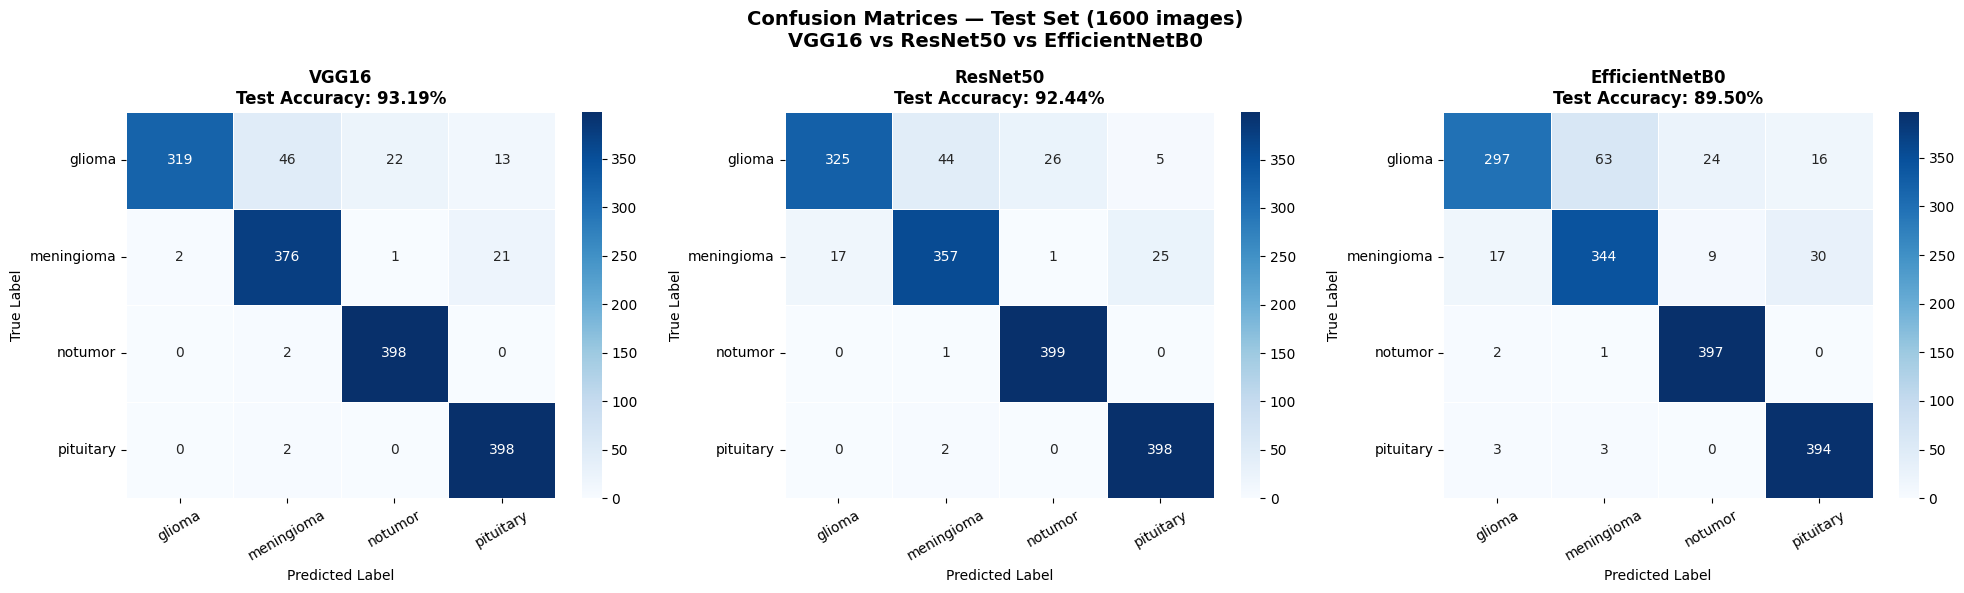

Confusion matrices saved to outputs folder.

FINAL COMPARISON — ALL THREE MODELS ON TEST SET
Model                  Accuracy  Precision     Recall   F1-Score
------------------------------------------------------------
VGG16                    93.19%     93.58%     93.19%     93.04%
ResNet50                 92.44%     92.51%     92.44%     92.29%
EfficientNetB0           89.50%     89.67%     89.50%     89.23%


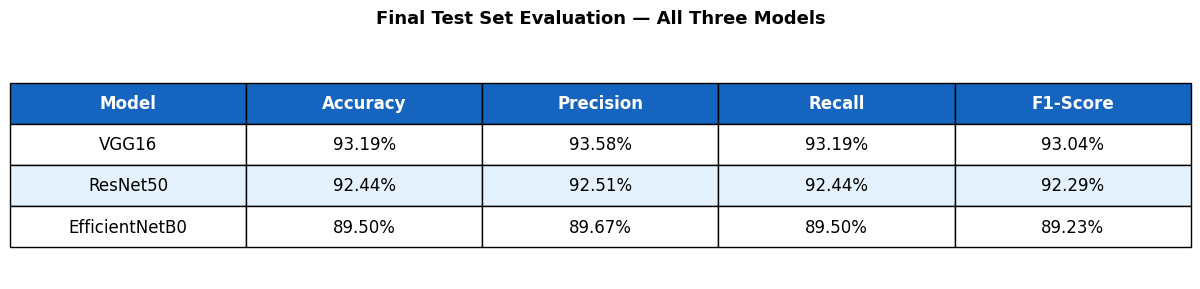

Final comparison table saved to outputs folder.


In [4]:
# ── PART 6: EVALUATION ON TEST SET ────────────────────────────────────────


# Step 1 — Reload Phase 2 models from saved dataset
# Models are saved in the Kaggle dataset you uploaded
# Update INPUT_PATH to match your dataset path

from tensorflow.keras.applications.vgg16        import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50     import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficient_preprocess

INPUT_PATH = '/kaggle/input/datasets/bbeastboy/brain-tumor-phase2-models/'

vgg_model = tf.keras.models.load_model(
    INPUT_PATH + 'VGG16_phase2_best.keras',
    custom_objects={'preprocess_input': vgg_preprocess}
)

resnet_model = tf.keras.models.load_model(
    INPUT_PATH + 'ResNet50_phase2_best.keras',
    custom_objects={'preprocess_input': resnet_preprocess}
)

efficientnet_model = tf.keras.models.load_model(
    INPUT_PATH + 'EfficientNetB0_phase2_best.keras',
    custom_objects={'preprocess_input': efficient_preprocess}
)

print("All three Phase 2 models loaded successfully.")
for name, model in [('VGG16', vgg_model),
                    ('ResNet50', resnet_model),
                    ('EfficientNetB0', efficientnet_model)]:
    print(f"  {name} — output shape: {model.output_shape} — params: {model.count_params():,}")


# Step 2 — Reset test generator before evaluation
# shuffle=False was already set — predictions will align with ground truth
test_generator.reset()


# Step 3 — Run predictions for all three models on the test set
print("\nGenerating predictions on test set...")

def get_predictions(model, generator):
    generator.reset()
    steps   = len(generator)
    preds   = model.predict(generator, steps=steps, verbose=1)
    y_pred  = np.argmax(preds, axis=1)
    y_true  = generator.classes
    return y_true, y_pred

y_true_vgg,  y_pred_vgg  = get_predictions(vgg_model,          test_generator)
y_true_res,  y_pred_res  = get_predictions(resnet_model,       test_generator)
y_true_eff,  y_pred_eff  = get_predictions(efficientnet_model, test_generator)

print("Predictions generated for all three models.")


# Step 4 — Classification reports
print("\n" + "=" * 50)
print("VGG16 — Classification Report")
print("=" * 50)
print(classification_report(y_true_vgg, y_pred_vgg,
                             target_names=CLASS_NAMES, digits=4))

print("=" * 50)
print("ResNet50 — Classification Report")
print("=" * 50)
print(classification_report(y_true_res, y_pred_res,
                             target_names=CLASS_NAMES, digits=4))

print("=" * 50)
print("EfficientNetB0 — Classification Report")
print("=" * 50)
print(classification_report(y_true_eff, y_pred_eff,
                             target_names=CLASS_NAMES, digits=4))


# Step 5 — Confusion matrices for all three models
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrices — Test Set (1600 images)\nVGG16 vs ResNet50 vs EfficientNetB0',
             fontsize=14, fontweight='bold')

models_data = [
    ('VGG16',          y_true_vgg, y_pred_vgg,  '#2196F3'),
    ('ResNet50',       y_true_res, y_pred_res,  '#F44336'),
    ('EfficientNetB0', y_true_eff, y_pred_eff,  '#4CAF50')
]

for ax, (name, y_true, y_pred, color) in zip(axes, models_data):

    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot      = True,
        fmt        = 'd',
        cmap       = 'Blues',
        xticklabels = CLASS_NAMES,
        yticklabels = CLASS_NAMES,
        ax         = ax,
        linewidths = 0.5
    )

    # Overall test accuracy
    acc = np.trace(cm) / np.sum(cm) * 100

    ax.set_title(f'{name}\nTest Accuracy: {acc:.2f}%',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrices.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrices saved to outputs folder.")


# Step 6 — Final comparison summary table
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("\n" + "=" * 60)
print("FINAL COMPARISON — ALL THREE MODELS ON TEST SET")
print("=" * 60)
print(f"{'Model':<20} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print("-" * 60)

summary_data = []

for name, y_true, y_pred in [('VGG16',          y_true_vgg, y_pred_vgg),
                               ('ResNet50',       y_true_res, y_pred_res),
                               ('EfficientNetB0', y_true_eff, y_pred_eff)]:

    acc  = accuracy_score(y_true,  y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec  = recall_score(y_true,   y_pred, average='weighted')
    f1   = f1_score(y_true,       y_pred, average='weighted')

    summary_data.append({
        'Model'    : name,
        'Accuracy' : acc,
        'Precision': prec,
        'Recall'   : rec,
        'F1-Score' : f1
    })

    print(f"{name:<20} {acc*100:>9.2f}% {prec*100:>9.2f}% {rec*100:>9.2f}% {f1*100:>9.2f}%")

print("=" * 60)


# Step 7 — Save summary table as figure
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('off')

table_data = [[d['Model'],
               f"{d['Accuracy']*100:.2f}%",
               f"{d['Precision']*100:.2f}%",
               f"{d['Recall']*100:.2f}%",
               f"{d['F1-Score']*100:.2f}%"]
              for d in summary_data]

table = ax.table(
    cellText  = table_data,
    colLabels = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'],
    cellLoc   = 'center',
    loc       = 'center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2.5)

for j in range(5):
    table[0, j].set_facecolor('#1565C0')
    table[0, j].set_text_props(color='white', fontweight='bold')

row_colors = ['#E3F2FD', '#FFFFFF']
for i in range(1, 4):
    for j in range(5):
        table[i, j].set_facecolor(row_colors[i % 2])

ax.set_title('Final Test Set Evaluation — All Three Models',
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'final_comparison_table.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Final comparison table saved to outputs folder.")

In [5]:
print(test_generator.samples)
print(test_generator.class_indices)

1600
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


# Part 7 — GradCAM Visualization

GradCAM stands for **Gradient-weighted Class Activation Mapping**. It is an explainability technique that shows us visually which regions of an MRI image each model focused on when making its classification decision.

It works by computing the gradients of the predicted class score with respect to the feature maps of the last convolutional layer. Regions with large gradients contributed more to the prediction and are highlighted in warm colors (red and yellow). Cool colors (blue) indicate regions the model ignored.

This is important for medical imaging because it lets us verify that the model is focusing on the actual tumor region and not on irrelevant background areas — which would indicate the model learned spurious correlations rather than genuine pathological features.

We generate heatmaps for one sample image from each class, for each of the three models. The result is a **4×3 grid** — 4 classes as rows, 3 models as columns.

---

## Last Convolutional Layers Used for GradCAM

| Model | Last Convolutional Layer |
|---|---|
| VGG16 | `block5_conv3` |
| ResNet50 | `conv5_block3_out` |
| EfficientNetB0 | `top_conv` |

In [3]:
from tensorflow.keras.applications.vgg16        import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50     import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficient_preprocess

INPUT_PATH = '/kaggle/input/datasets/bbeastboy/brain-tumor-phase2-models/'

vgg_model = tf.keras.models.load_model(
    INPUT_PATH + 'VGG16_phase2_best.keras',
    custom_objects={'preprocess_input': vgg_preprocess}
)
resnet_model = tf.keras.models.load_model(
    INPUT_PATH + 'ResNet50_phase2_best.keras',
    custom_objects={'preprocess_input': resnet_preprocess}
)
efficientnet_model = tf.keras.models.load_model(
    INPUT_PATH + 'EfficientNetB0_phase2_best.keras',
    custom_objects={'preprocess_input': efficient_preprocess}
)
print("All three models loaded.")

All three models loaded.


Collected correctly classified images: ['glioma', 'meningioma', 'notumor', 'pituitary']


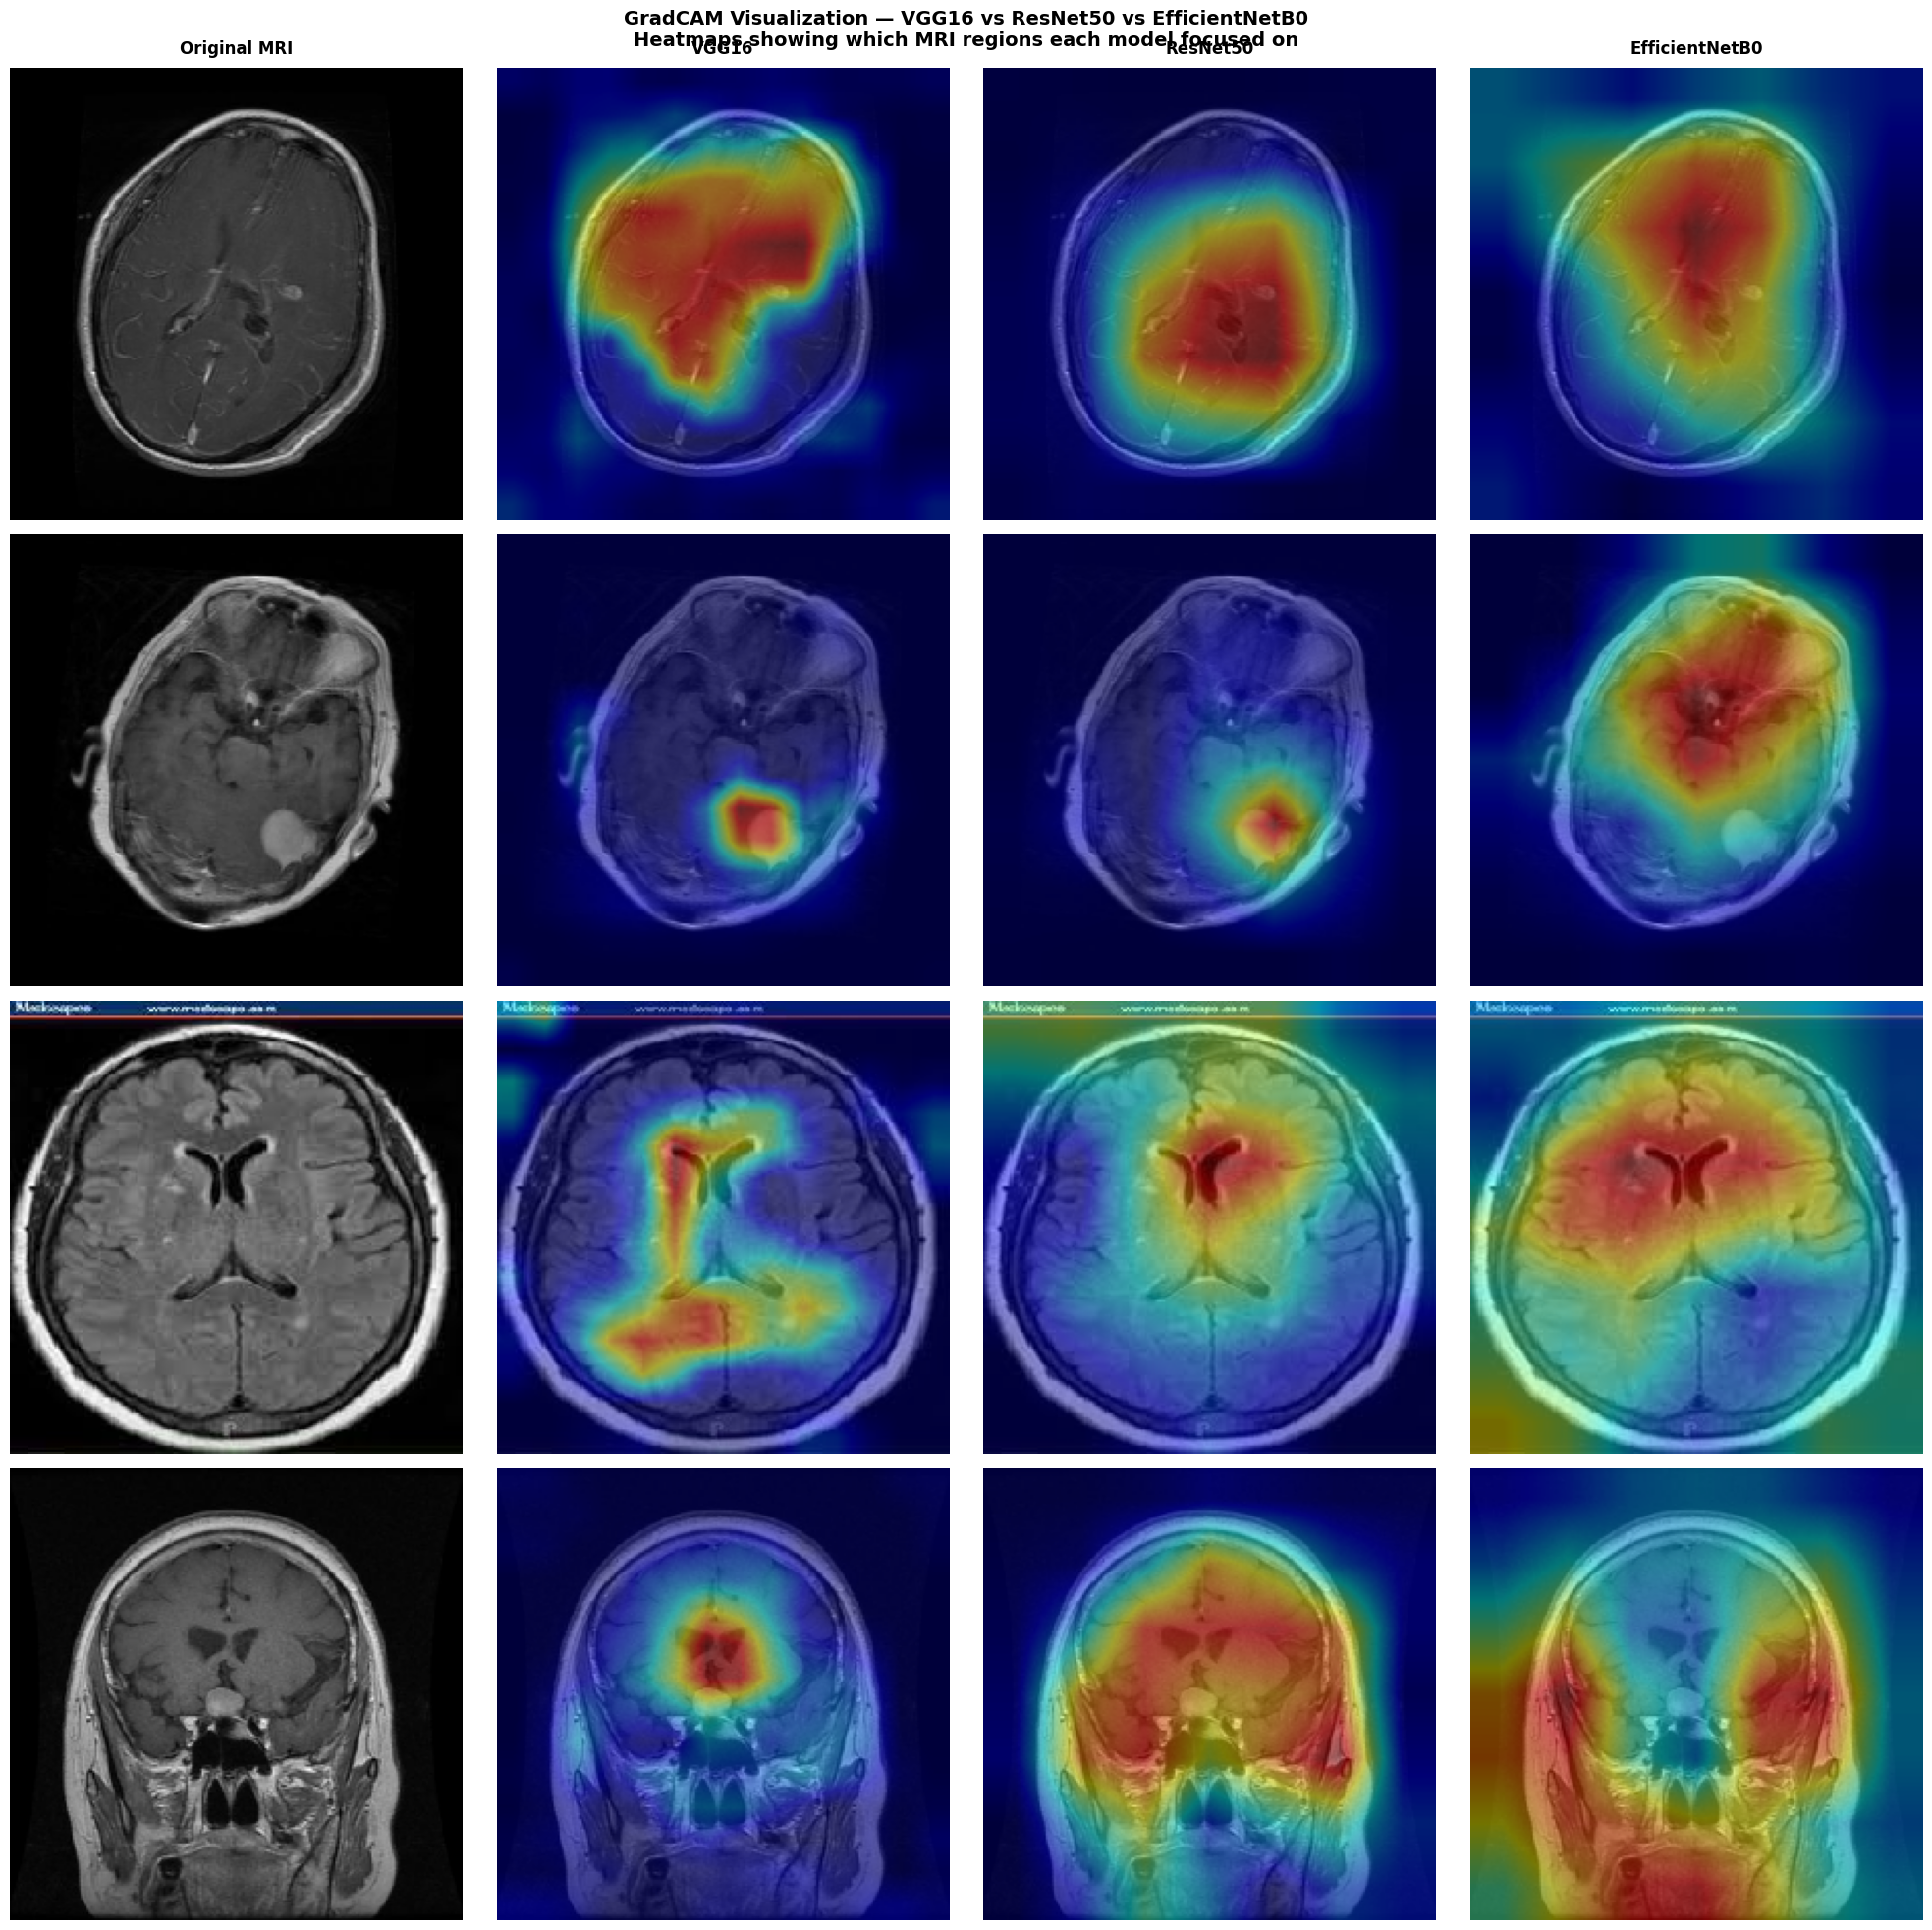

GradCAM visualization saved to outputs folder.

Model prediction confidence for each sample image:
------------------------------------------------------------

  True class: GLIOMA
    VGG16                → glioma       (100.00%) ✓
    ResNet50             → glioma       (100.00%) ✓
    EfficientNetB0       → glioma       (100.00%) ✓

  True class: MENINGIOMA
    VGG16                → meningioma   (99.81%) ✓
    ResNet50             → meningioma   (99.81%) ✓
    EfficientNetB0       → meningioma   (92.00%) ✓

  True class: NOTUMOR
    VGG16                → notumor      (100.00%) ✓
    ResNet50             → notumor      (100.00%) ✓
    EfficientNetB0       → notumor      (100.00%) ✓

  True class: PITUITARY
    VGG16                → pituitary    (100.00%) ✓
    ResNet50             → pituitary    (100.00%) ✓
    EfficientNetB0       → pituitary    (99.31%) ✓


In [9]:
# ── PART 7: GRADCAM VISUALIZATION (FIXED) ─────────────────────────────────



def get_gradcam_heatmap(model, img_array, class_idx, model_name):

    base = model.layers[2]

    conv_layer_names = {
        'VGG16'         : 'block5_conv3',
        'ResNet50'      : 'conv5_block3_out',
        'EfficientNetB0': 'top_conv'
    }
    conv_layer_name = conv_layer_names[model_name]

    # Step 1 — Build model from base input to conv layer output only
    conv_model = tf.keras.Model(
        inputs  = base.inputs,
        outputs = base.get_layer(conv_layer_name).output
    )

    # Step 2 — Get preprocessed input through Lambda layer
    lambda_layer = model.layers[1]
    img_f32      = tf.cast(img_array, tf.float32)
    preprocessed = tf.cast(lambda_layer(img_f32), tf.float32)

    # Step 3 — Get conv layer feature maps (no gradient needed here)
    conv_out = conv_model(preprocessed, training=False)
    conv_out = conv_out[0].numpy().astype(np.float32)  # (H, W, C)

    # Step 4 — Get final Dense layer weights for the target class
    # Dense layer is model.layers[-1]
    dense_weights = model.layers[-1].get_weights()[0]  # shape (units_in, 4)
    class_weights = dense_weights[:, class_idx]         # shape (units_in,)

    # Step 5 — GlobalAveragePooling maps conv (H,W,C) → (C,)
    # The Dense layer connects GAP output to class scores
    # GradCAM = sum of (class_weight_per_channel * feature_map_per_channel)
    # This is the CAM formula — valid when GAP precedes Dense directly

    # Number of channels in conv output
    n_channels = conv_out.shape[-1]

    # class_weights may be larger than n_channels if GAP output != conv channels
    # Use only first n_channels weights
    if len(class_weights) >= n_channels:
        weights = class_weights[:n_channels]
    else:
        weights = class_weights

    # Weighted sum across channels
    heatmap = np.zeros(conv_out.shape[:2], dtype=np.float32)
    for i, w in enumerate(weights):
        heatmap += w * conv_out[:, :, i]

    # ReLU and normalize
    heatmap = np.nan_to_num(heatmap, nan=0.0)
    heatmap = np.maximum(heatmap, 0)
    max_val = np.max(heatmap)
    if max_val > 0:
        heatmap = heatmap / max_val

    return heatmap.astype(np.float32)
 
    
# Step 2 — Overlay heatmap on original image
def overlay_gradcam(original_img, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(heatmap,
                                  (original_img.shape[1], original_img.shape[0]))
    heatmap_colored = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET
    )
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    overlaid = cv2.addWeighted(
        original_img.astype(np.uint8), 1 - alpha,
        heatmap_colored,               alpha,
        0
    )
    return overlaid


# Step 3 — Model dict
models_dict = {
    'VGG16'         : vgg_model,
    'ResNet50'      : resnet_model,
    'EfficientNetB0': efficientnet_model
}


# Step 4 — Collect ONE CORRECTLY CLASSIFIED image per class
print("Collecting correctly classified sample images...")

test_generator.reset()

sample_images = {cls: None for cls in CLASS_NAMES}
sample_labels = {cls: idx for cls, idx in test_generator.class_indices.items()}

# Keep fetching batches until we have one correct image per class
while any(v is None for v in sample_images.values()):
    batch_imgs, batch_lbls = next(test_generator)

    for i in range(len(batch_imgs)):
        label_idx  = np.argmax(batch_lbls[i])
        class_name = CLASS_NAMES[label_idx]

        if sample_images[class_name] is not None:
            continue

        # Check if VGG16 classifies this correctly
        img_arr  = np.expand_dims(batch_imgs[i], axis=0)
        pred_idx = np.argmax(vgg_model.predict(img_arr, verbose=0)[0])

        if pred_idx == label_idx:
            sample_images[class_name] = batch_imgs[i]

print(f"Collected correctly classified images: {list(sample_images.keys())}")


# Step 5 — Generate GradCAM grid
fig, axes = plt.subplots(
    len(CLASS_NAMES), len(models_dict) + 1,
    figsize=(20, 20)
)

fig.suptitle(
    'GradCAM Visualization — VGG16 vs ResNet50 vs EfficientNetB0\n'
    'Heatmaps showing which MRI regions each model focused on',
    fontsize=14, fontweight='bold'
)

col_titles = ['Original MRI', 'VGG16', 'ResNet50', 'EfficientNetB0']
for col, title in enumerate(col_titles):
    axes[0][col].set_title(title, fontsize=12, fontweight='bold', pad=10)

for row, class_name in enumerate(CLASS_NAMES):

    img       = sample_images[class_name]
    img_uint8 = img.clip(0, 255).astype(np.uint8)
    img_array = np.expand_dims(img, axis=0)
    class_idx = sample_labels[class_name]

    # Column 0 — original image
    axes[row][0].imshow(img_uint8)
    axes[row][0].set_ylabel(class_name.upper(),
                             fontsize=11, fontweight='bold',
                             rotation=90, labelpad=10)
    axes[row][0].axis('off')

    # Columns 1-3 — GradCAM per model
    for col, (model_name, model) in enumerate(models_dict.items(), start=1):
        try:
            heatmap  = get_gradcam_heatmap(model, img_array,
                                            class_idx, model_name)
            overlaid = overlay_gradcam(img_uint8, heatmap, alpha=0.45)
            axes[row][col].imshow(overlaid)
        except Exception as e:
            axes[row][col].text(0.5, 0.5, f'Error:\n{str(e)[:80]}',
                                ha='center', va='center',
                                fontsize=7, color='red',
                                transform=axes[row][col].transAxes)
        axes[row][col].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'gradcam_results.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("GradCAM visualization saved to outputs folder.")


# Step 6 — Confidence printout
print("\nModel prediction confidence for each sample image:")
print("-" * 60)

for class_name in CLASS_NAMES:
    img       = sample_images[class_name]
    img_array = np.expand_dims(img, axis=0)
    true_idx  = sample_labels[class_name]

    print(f"\n  True class: {class_name.upper()}")

    for model_name, model in models_dict.items():
        preds      = model.predict(img_array, verbose=0)[0]
        pred_idx   = np.argmax(preds)
        pred_class = CLASS_NAMES[pred_idx]
        confidence = preds[pred_idx] * 100
        correct    = '✓' if pred_idx == true_idx else '✗'
        print(f"    {model_name:<20} → {pred_class:<12} ({confidence:.2f}%) {correct}")

# Part 8 — Final Comparison & Summary

This is the final part of the project. In this section, we consolidate all results obtained from Phase 1 baseline training, Phase 2 fine-tuning, and final test set evaluation into a single comprehensive comparison framework. The goal is to analyze and compare the overall performance of every trained model using consistent evaluation metrics and visual summaries.

We regenerate predictions on the test dataset, compute all major evaluation metrics, and generate the complete set of comparative visualizations. These include training and validation curves, metric comparison bar charts, per-model performance curves, confusion matrix summaries, and a final ranked results table highlighting the best-performing models across all evaluation criteria.

Generating test set predictions...
Predictions ready.

Final Test Set Results:
Model                  Accuracy  Precision     Recall         F1
-------------------------------------------------------
VGG16                    93.19%     93.58%     93.19%     93.04%
ResNet50                 92.44%     92.51%     92.44%     92.29%
EfficientNetB0           89.50%     89.67%     89.50%     89.23%


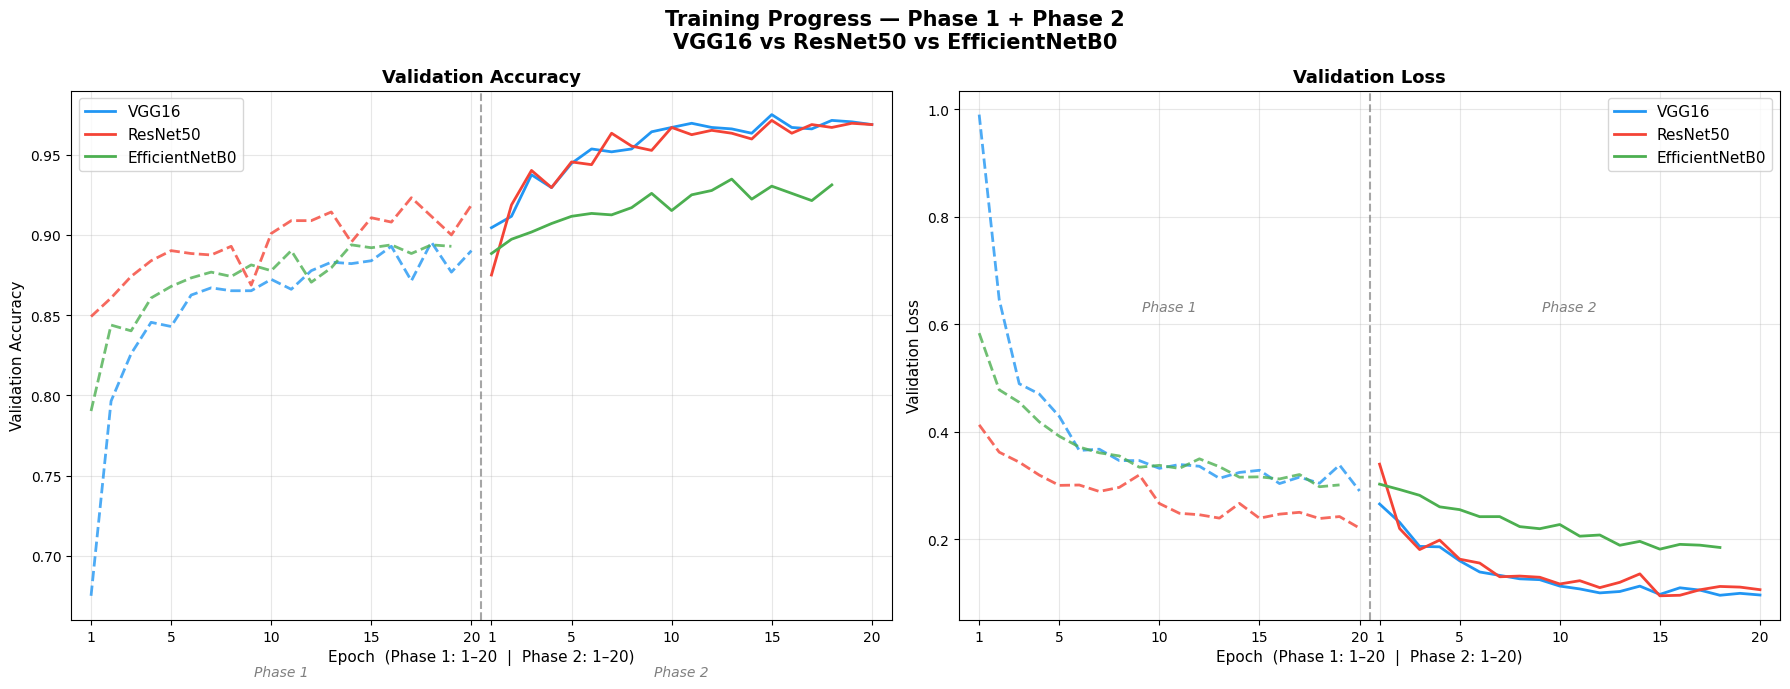

Training curves saved.


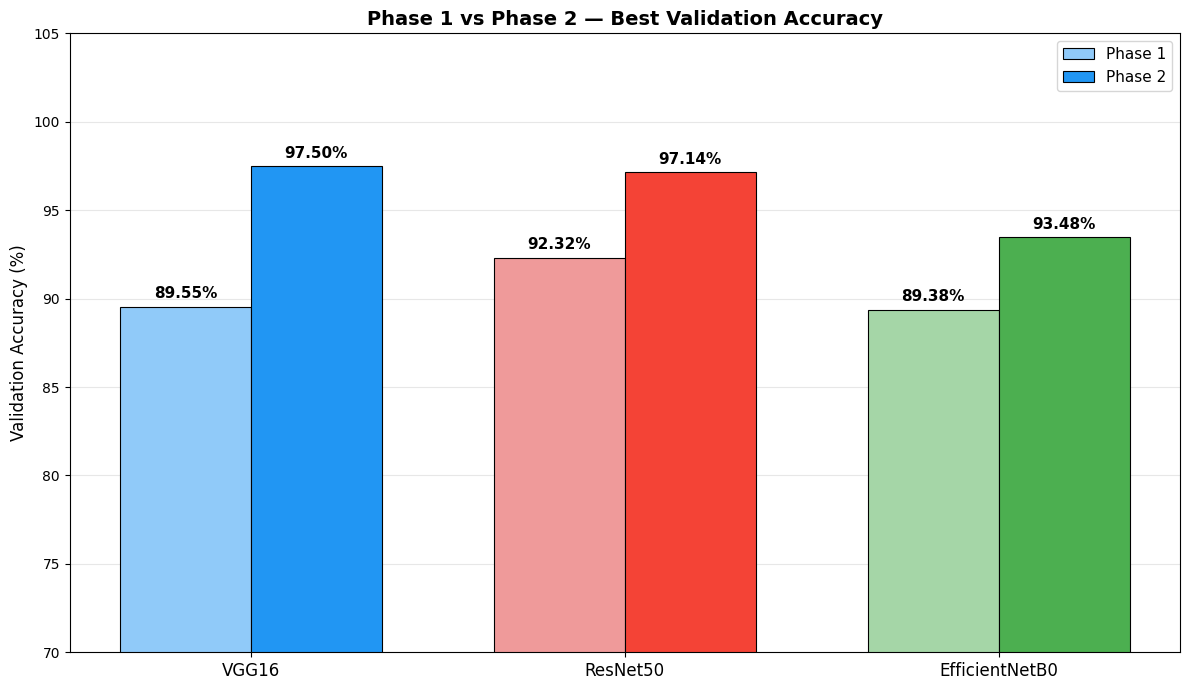

Bar chart saved.


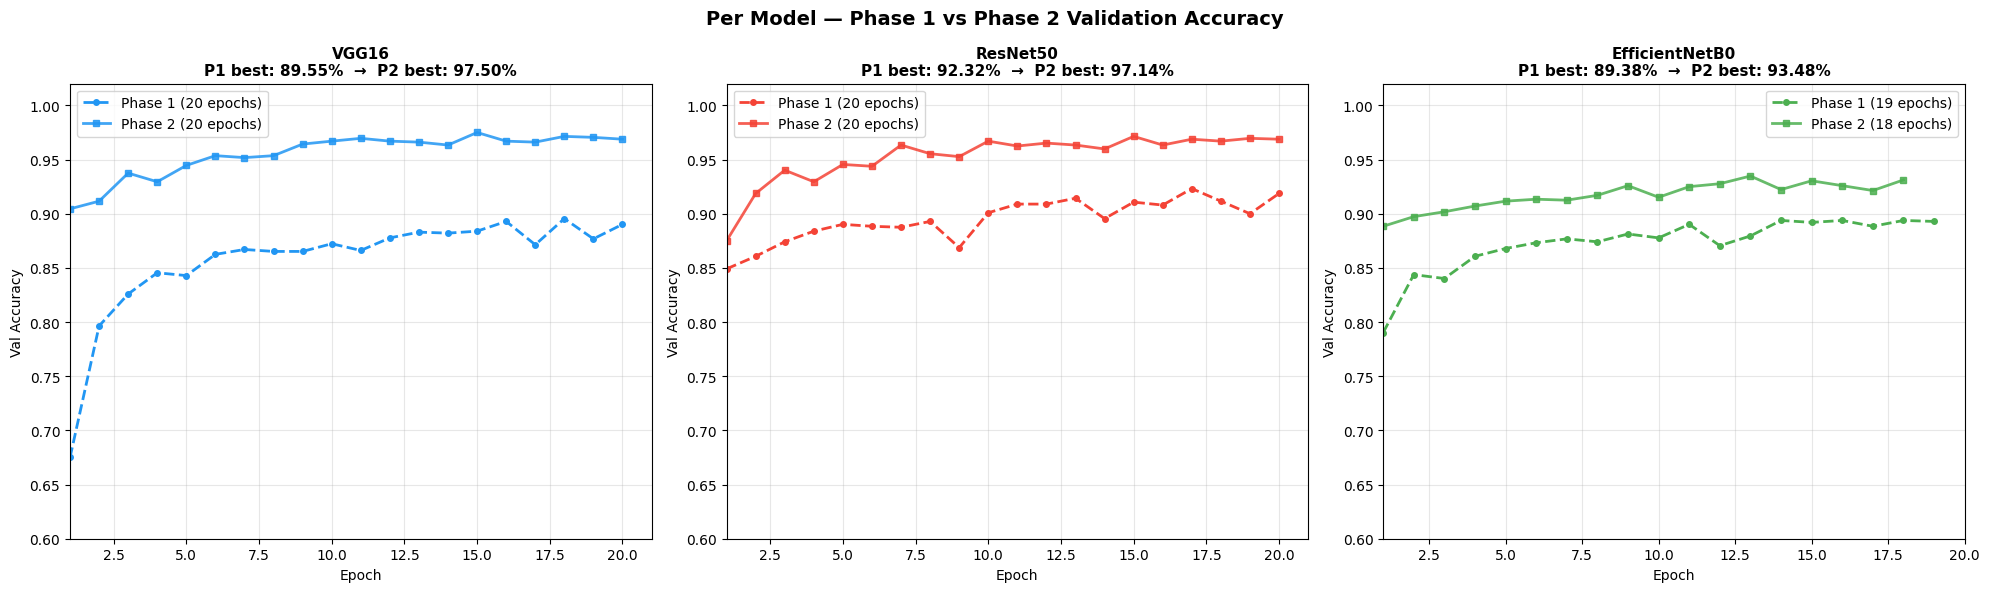

Per model curves saved.


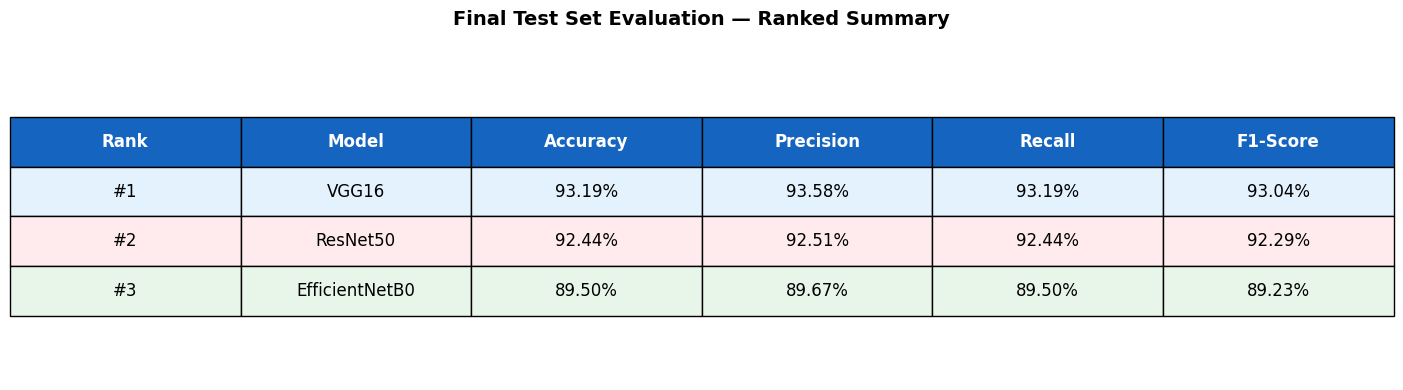

Final ranked table saved.

PROJECT COMPLETE — FINAL SUMMARY

Dataset  : Brain Tumor MRI — 4 classes, 7200 images
Test set : 1600 images (400 per class)

Phase 1 Training (Frozen Base):
  VGG16          : 89.55% val accuracy
  ResNet50       : 92.32% val accuracy
  EfficientNetB0 : 89.38% val accuracy

Phase 2 Fine-tuning (Functional Depth Matching):
  VGG16          : 97.50% val accuracy  (+7.95%)
  ResNet50       : 97.14% val accuracy  (+4.82%)
  EfficientNetB0 : 93.48% val accuracy  (+4.10%)

Final Test Set Accuracy:
  VGG16                : 93.19%
  ResNet50             : 92.44%
  EfficientNetB0       : 89.50%

Outputs saved to: /kaggle/working/outputs


In [13]:
# ── PART 8: FINAL COMPARISON & SUMMARY ────────────────────────────────────


# Step 1 — Regenerate test predictions for all three models
print("Generating test set predictions...")

def get_predictions(model, generator):
    generator.reset()
    steps  = len(generator)
    preds  = model.predict(generator, steps=steps, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = generator.classes
    return y_true, y_pred

y_true_vgg, y_pred_vgg = get_predictions(vgg_model,          test_generator)
y_true_res, y_pred_res = get_predictions(resnet_model,       test_generator)
y_true_eff, y_pred_eff = get_predictions(efficientnet_model, test_generator)

print("Predictions ready.")


# Step 2 — Compute metrics for all three models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def compute_metrics(y_true, y_pred, name):
    return {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_true,  y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted'),
        'Recall'   : recall_score(y_true,   y_pred, average='weighted'),
        'F1-Score' : f1_score(y_true,       y_pred, average='weighted')
    }

metrics = [
    compute_metrics(y_true_vgg, y_pred_vgg, 'VGG16'),
    compute_metrics(y_true_res, y_pred_res, 'ResNet50'),
    compute_metrics(y_true_eff, y_pred_eff, 'EfficientNetB0')
]

print("\nFinal Test Set Results:")
print(f"{'Model':<20} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 55)
for m in metrics:
    print(f"{m['Model']:<20} {m['Accuracy']*100:>9.2f}% "
          f"{m['Precision']*100:>9.2f}% "
          f"{m['Recall']*100:>9.2f}% "
          f"{m['F1-Score']*100:>9.2f}%")


# Step 3 — Training curves (from hardcoded epoch logs)
p1_vgg_val_acc  = [0.6750,0.7964,0.8259,0.8455,0.8429,0.8625,0.8670,
                   0.8652,0.8652,0.8723,0.8661,0.8777,0.8830,0.8821,
                   0.8839,0.8929,0.8714,0.8955,0.8768,0.8902]
p1_res_val_acc  = [0.8491,0.8607,0.8741,0.8839,0.8902,0.8884,0.8875,
                   0.8929,0.8687,0.9009,0.9089,0.9089,0.9143,0.8955,
                   0.9107,0.9080,0.9232,0.9116,0.9000,0.9187]
p1_eff_val_acc  = [0.7902,0.8438,0.8402,0.8607,0.8679,0.8732,0.8768,
                   0.8741,0.8813,0.8777,0.8902,0.8705,0.8795,0.8938,
                   0.8920,0.8938,0.8884,0.8938,0.8929]
p1_vgg_val_loss = [0.9898,0.6460,0.4892,0.4701,0.4285,0.3651,0.3674,
                   0.3462,0.3462,0.3318,0.3389,0.3357,0.3133,0.3242,
                   0.3282,0.3035,0.3154,0.3041,0.3379,0.2897]
p1_res_val_loss = [0.4127,0.3619,0.3433,0.3193,0.3001,0.3008,0.2888,
                   0.2964,0.3196,0.2664,0.2482,0.2455,0.2392,0.2666,
                   0.2390,0.2466,0.2500,0.2385,0.2421,0.2206]
p1_eff_val_loss = [0.5833,0.4779,0.4547,0.4183,0.3916,0.3714,0.3607,
                   0.3549,0.3339,0.3374,0.3317,0.3495,0.3348,0.3153,
                   0.3160,0.3121,0.3203,0.2976,0.3010]
p2_vgg_val_acc  = [0.9045,0.9116,0.9375,0.9295,0.9446,0.9536,0.9518,
                   0.9536,0.9643,0.9670,0.9696,0.9670,0.9661,0.9634,
                   0.9750,0.9670,0.9661,0.9714,0.9705,0.9688]
p2_res_val_acc  = [0.8750,0.9187,0.9402,0.9295,0.9455,0.9438,0.9634,
                   0.9554,0.9527,0.9670,0.9625,0.9652,0.9634,0.9598,
                   0.9714,0.9634,0.9688,0.9670,0.9696,0.9688]
p2_eff_val_acc  = [0.8884,0.8973,0.9018,0.9071,0.9116,0.9134,0.9125,
                   0.9170,0.9259,0.9152,0.9250,0.9277,0.9348,0.9223,
                   0.9304,0.9259,0.9214,0.9312]
p2_vgg_val_loss = [0.2655,0.2314,0.1866,0.1858,0.1598,0.1390,0.1327,
                   0.1263,0.1247,0.1128,0.1075,0.1001,0.1027,0.1127,
                   0.0973,0.1096,0.1053,0.0957,0.0993,0.0962]
p2_res_val_loss = [0.3396,0.2198,0.1807,0.1983,0.1628,0.1556,0.1301,
                   0.1314,0.1292,0.1167,0.1228,0.1099,0.1198,0.1355,
                   0.0947,0.0957,0.1059,0.1121,0.1109,0.1061]
p2_eff_val_loss = [0.3024,0.2924,0.2816,0.2602,0.2550,0.2419,0.2420,
                   0.2234,0.2195,0.2273,0.2056,0.2078,0.1887,0.1960,
                   0.1815,0.1904,0.1889,0.1846]

colors = {
    'VGG16'         : '#2196F3',
    'ResNet50'      : '#F44336',
    'EfficientNetB0': '#4CAF50'
}

p1_epochs = 20
tick_positions = [1, 5, 10, 15, 20, 21, 25, 30, 35, 40]
tick_labels    = ['1','5','10','15','20','1','5','10','15','20']


# Step 4 — Graph 1: Training curves
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Training Progress — Phase 1 + Phase 2\nVGG16 vs ResNet50 vs EfficientNetB0',
             fontsize=15, fontweight='bold')

for ax, (p1_list, p2_list, title, ylabel) in zip(axes, [
    ([p1_vgg_val_acc, p1_res_val_acc, p1_eff_val_acc],
     [p2_vgg_val_acc, p2_res_val_acc, p2_eff_val_acc],
     'Validation Accuracy', 'Validation Accuracy'),
    ([p1_vgg_val_loss, p1_res_val_loss, p1_eff_val_loss],
     [p2_vgg_val_loss, p2_res_val_loss, p2_eff_val_loss],
     'Validation Loss', 'Validation Loss')
]):
    names  = ['VGG16', 'ResNet50', 'EfficientNetB0']
    clrs   = [colors['VGG16'], colors['ResNet50'], colors['EfficientNetB0']]
    for p1, color, name in zip(p1_list, clrs, names):
        ax.plot(range(1, len(p1)+1), p1,
                color=color, linewidth=2, linestyle='--', alpha=0.8)
    for p2, color, name in zip(p2_list, clrs, names):
        ax.plot(range(p1_epochs+1, p1_epochs+len(p2)+1), p2,
                color=color, linewidth=2, linestyle='-', label=name)
    ax.axvline(x=p1_epochs+0.5, color='gray', linestyle='--',
               linewidth=1.5, alpha=0.7)
    ax.text(10.5, 0.625, 'Phase 1', fontsize=10,
            color='gray', fontstyle='italic', ha='center')
    ax.text(30.5, 0.625, 'Phase 2', fontsize=10,
            color='gray', fontstyle='italic', ha='center')
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.set_xlim([0, 41])
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch  (Phase 1: 1–20  |  Phase 2: 1–20)', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves_full.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved.")


# Step 5 — Graph 2: Phase 1 vs Phase 2 bar chart
fig, ax = plt.subplots(figsize=(12, 7))

model_names = ['VGG16', 'ResNet50', 'EfficientNetB0']
p1_best     = [89.55, 92.32, 89.38]
p2_best     = [97.50, 97.14, 93.48]
x           = np.arange(len(model_names))
width       = 0.35

bars1 = ax.bar(x - width/2, p1_best, width, label='Phase 1',
               color=['#90CAF9','#EF9A9A','#A5D6A7'],
               edgecolor='black', linewidth=0.8)
bars2 = ax.bar(x + width/2, p2_best, width, label='Phase 2',
               color=['#2196F3','#F44336','#4CAF50'],
               edgecolor='black', linewidth=0.8)

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{bar.get_height():.2f}%', ha='center', va='bottom',
            fontsize=11, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{bar.get_height():.2f}%', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.set_title('Phase 1 vs Phase 2 — Best Validation Accuracy',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Validation Accuracy (%)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=12)
ax.set_ylim([70, 105])
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase_comparison_bar.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Bar chart saved.")


# Step 6 — Graph 3: Per model curves
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Per Model — Phase 1 vs Phase 2 Validation Accuracy',
             fontsize=14, fontweight='bold')

data = [
    ('VGG16',          p1_vgg_val_acc, p2_vgg_val_acc, colors['VGG16']),
    ('ResNet50',       p1_res_val_acc, p2_res_val_acc, colors['ResNet50']),
    ('EfficientNetB0', p1_eff_val_acc, p2_eff_val_acc, colors['EfficientNetB0'])
]

for ax, (name, p1, p2, color) in zip(axes, data):
    ax.plot(range(1, len(p1)+1), p1, color=color, linewidth=2,
            linestyle='--', label=f'Phase 1 ({len(p1)} epochs)',
            marker='o', markersize=4)
    ax.plot(range(1, len(p2)+1), p2, color=color, linewidth=2,
            linestyle='-',  label=f'Phase 2 ({len(p2)} epochs)',
            marker='s', markersize=4, alpha=0.85)
    ax.set_title(f'{name}\nP1 best: {max(p1)*100:.2f}%  →  P2 best: {max(p2)*100:.2f}%',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel('Val Accuracy', fontsize=10)
    ax.set_ylim([0.60, 1.02])
    ax.set_xlim([1, max(len(p1), len(p2))+1])
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'per_model_curves.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Per model curves saved.")


# Step 7 — Final ranked summary table
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('off')

# Sort by accuracy descending
metrics_sorted = sorted(metrics, key=lambda x: x['Accuracy'], reverse=True)

table_data = []
for rank, m in enumerate(metrics_sorted, 1):
    table_data.append([
        f"#{rank}",
        m['Model'],
        f"{m['Accuracy']*100:.2f}%",
        f"{m['Precision']*100:.2f}%",
        f"{m['Recall']*100:.2f}%",
        f"{m['F1-Score']*100:.2f}%"
    ])

table = ax.table(
    cellText  = table_data,
    colLabels = ['Rank', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'],
    cellLoc   = 'center',
    loc       = 'center'
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2.8)

# Header
for j in range(6):
    table[0, j].set_facecolor('#1565C0')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Row colors matching model colors
row_bg = ['#E3F2FD', '#FFEBEE', '#E8F5E9']
for i in range(1, 4):
    for j in range(6):
        table[i, j].set_facecolor(row_bg[i-1])

ax.set_title('Final Test Set Evaluation — Ranked Summary',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'final_ranked_table.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Final ranked table saved.")


# Step 8 — Print complete project summary
print("\n" + "=" * 60)
print("PROJECT COMPLETE — FINAL SUMMARY")
print("=" * 60)
print(f"\nDataset  : Brain Tumor MRI — 4 classes, 7200 images")
print(f"Test set : 1600 images (400 per class)")
print(f"\nPhase 1 Training (Frozen Base):")
print(f"  VGG16          : 89.55% val accuracy")
print(f"  ResNet50       : 92.32% val accuracy")
print(f"  EfficientNetB0 : 89.38% val accuracy")
print(f"\nPhase 2 Fine-tuning (Functional Depth Matching):")
print(f"  VGG16          : 97.50% val accuracy  (+7.95%)")
print(f"  ResNet50       : 97.14% val accuracy  (+4.82%)")
print(f"  EfficientNetB0 : 93.48% val accuracy  (+4.10%)")
print(f"\nFinal Test Set Accuracy:")
for m in metrics_sorted:
    print(f"  {m['Model']:<20} : {m['Accuracy']*100:.2f}%")
print(f"\nOutputs saved to: {OUTPUT_DIR}")
print("=" * 60)